# Optuna Study Analysis
Scalarised smooth-crossing study: `score = 0.65 * success_rate − 0.35 * shock_p99_normalised`

Sections:
1. Load study & build dataframe
2. Top trials table
3. Success rate vs shock trade-off scatter
4. Parameter vs score / success_rate / shock scatter plots
5. Sampling convergence over time
6. Correlation matrix
7. fANOVA parameter importance
8. GP surrogate model + 1-D marginal slices

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
STUDY_NAME = "ftr_optuna_smooth_v2"
LOG_DIR    = None   # set to a log dir path to auto-read study name from its config copy

DB_PATH = "/home/robot/workspaces/robot_rodeo_gym_ws/optuna/optuna.db"

# Set to a trial number to cap data at that point (historical snapshot).
# None = use all available trials.
MAX_TRIAL = 240

# Scalarised objective weights — must match optuna_ftr_smooth.yaml metric_weights.
# Used to reconstruct score for trials that pre-date user-attr logging.
METRIC_WEIGHTS = {
    "eval/success_rate":          0.65,
    "eval/shock_p99_normalised": -0.35,
}


In [4]:
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Resolve study name ────────────────────────────────────────────────────────
study_name = STUDY_NAME
if LOG_DIR is not None:
    import yaml
    for fname in ("optuna_ftr_smooth.yaml", "optuna_ftr.yaml"):
        p = Path(LOG_DIR) / fname
        if p.exists():
            study_name = yaml.safe_load(p.read_text())["study_name"]
            print(f"Resolved study name from {fname}: {study_name}")
            break

# ── Load study ────────────────────────────────────────────────────────────────
storage = optuna.storages.RDBStorage(f"sqlite:///{DB_PATH}")
study   = optuna.load_study(study_name=study_name, storage=storage)

all_trials = study.trials
if MAX_TRIAL is not None:
    all_trials = [t for t in all_trials if t.number <= MAX_TRIAL]
    print(f"Snapshot : trials 0 – {MAX_TRIAL}")
trials     = [t for t in all_trials if t.state == optuna.trial.TrialState.COMPLETE]
print(f"Study : {study_name}")
print(f"Trials: {len(all_trials)} total | {len(trials)} complete | "
      f"{sum(1 for t in all_trials if t.state == optuna.trial.TrialState.FAIL)} fail | "
      f"{sum(1 for t in all_trials if t.state == optuna.trial.TrialState.RUNNING)} running | "
      f"{sum(1 for t in all_trials if t.state == optuna.trial.TrialState.PRUNED)} pruned")

if not trials:
    raise RuntimeError("No completed trials found.")

# ── Build dataframe ───────────────────────────────────────────────────────────
component_keys = list(METRIC_WEIGHTS.keys())

records = []
for t in trials:
    # t.values is None for trials manually promoted to COMPLETE via SQL without
    # a proper Optuna tell() call — fall back to the score user attr in that case.
    score = t.values[0] if t.values else t.user_attrs.get("score", float("nan"))
    row = {"trial": t.number, "score": score}
    for k in component_keys:
        row[k] = t.user_attrs.get(k, float("nan"))
    row.update(t.params)
    records.append(row)

df = pd.DataFrame(records).sort_values("trial").reset_index(drop=True)

has_components = df[component_keys].notna().all(axis=1)
print(f"nTrials with component metrics: {has_components.sum()}/{len(df)}")

sr_col = "eval/success_rate"

# Auto-detect shock column: prefer p99-normalised (v2+), fall back to old mean-normalised (v1).
_shock_candidates = ["eval/shock_p99_normalised", "eval/shock_normalised"]
shock_col = next((c for c in _shock_candidates if c in df.columns and df[c].notna().any()), None)
if shock_col is None:
    # Column exists but all-NaN (no completed trials with shock data yet) — keep as placeholder
    shock_col = component_keys[1] if len(component_keys) > 1 else _shock_candidates[0]
    # Ensure the column exists so downstream cells don't KeyError
    if shock_col not in df.columns:
        df[shock_col] = float("nan")
print(f"Shock metric : {shock_col}")

print(f"\nBest trial by score: #{df.loc[df['score'].idxmax(), 'trial']:.0f}  "
      f"score={df['score'].max():.4f}")
print(f"min {df[sr_col].min():.4f}, max {df[sr_col].max():.4f}")
if has_components.any():
    sub = df[has_components]
    sr_val = sub.loc[sub['score'].idxmax(), sr_col]
    sh_val = sub.loc[sub['score'].idxmax(), shock_col] if shock_col in sub.columns else float("nan")
    print(f"  → success_rate={sr_val:.3f}  {shock_col.split('/')[-1]}={sh_val:.4f}")
df.head()

Snapshot : trials 0 – 240
Study : ftr_optuna_smooth_v2
Trials: 241 total | 154 complete | 54 fail | 0 running | 33 pruned
nTrials with component metrics: 150/154
Shock metric : eval/shock_p99_normalised

Best trial by score: #160  score=0.3966
min 0.0000, max 0.7270
  → success_rate=0.727  shock_p99_normalised=0.2170


,trial,score,eval/success_rate,eval/shock_p99_normalised,env_cfg_overrides.goal_reached_reward,env_cfg_overrides.failed_reward,env_cfg_overrides.shaping_coef,env_cfg_overrides.step_penalty,env_cfg_overrides.action_bonus_coef,env_cfg_overrides.flipper_action_bonus_coef,...,gae_opts.lmbda,policy_opts.actor_mlp_opts.num_hidden,policy_opts.actor_mlp_opts.hidden_dim,policy_opts.value_mlp_opts.num_hidden,policy_opts.value_mlp_opts.hidden_dim,ftr_obs_encoder_opts.num_hidden,policy_opts.actor_optimizer_opts.lr,policy_opts.value_optimizer_opts.lr,ppo_opts.clip_epsilon,max_grad_norm
0,8,0.023711,0.133671,0.180500,280.982437,-91.360477,62.246526,-0.077732,2.672769,0.217129,...,0.901276,2,128,2,128,2,0.000277,0.000803,NaN,NaN
1,9,0.010286,0.088894,0.135700,185.156793,-90.590423,42.183375,-0.433477,14.929465,5.195419,...,0.905115,3,256,3,256,2,0.003624,0.000217,NaN,NaN
2,11,-0.043699,0.000000,0.124854,119.029164,-47.681109,17.426342,-0.947373,12.620049,6.634869,...,0.910483,2,256,2,128,3,0.009298,0.035480,NaN,NaN
3,12,-0.001991,0.100268,0.191900,216.851460,-53.528801,68.207043,-0.805738,16.211340,8.394750,...,0.922027,2,64,2,256,2,0.003964,0.002803,NaN,NaN
4,13,-0.023453,0.091426,0.236800,288.004353,-14.577084,76.782303,-0.223253,4.632325,6.902415,...,0.908911,2,128,2,256,3,0.000115,0.000122,NaN,NaN


In [5]:
# ── Detect parameter types & log-scale params ─────────────────────────────────
non_param_cols = {"trial", "score", sr_col, shock_col}
param_names = [c for c in df.columns if c not in non_param_cols]

categorical_params = set()
for name in param_names:
    col = df[name]
    if not np.issubdtype(col.dtype, np.number) or col.nunique() <= 6:
        categorical_params.add(name)

continuous_params  = [p for p in param_names if p not in categorical_params]
categorical_params = [p for p in param_names if p in categorical_params]

# Explicit log-scale list — only params that are truly tiny-valued (e.g. LR, entropy)
LOG_SCALE_KEYWORDS = {"lr", "entropy_coef", "shock_coef"}
log_params = {p for p in continuous_params
              if p.rsplit(".", 1)[-1] in LOG_SCALE_KEYWORDS
              and df[p].dropna().min() > 0}

# Short display names
from collections import Counter
def _build_short_names(names):
    mapping = {n: n.rsplit(".", 1)[-1] for n in names}
    counts  = Counter(mapping.values())
    for full, short in list(mapping.items()):
        if counts[short] > 1:
            parts = full.split(".")
            mapping[full] = ".".join(parts[-2:]) if len(parts) >= 2 else short
    return mapping

_short_name_map = _build_short_names(param_names)
def short_name(name):
    return _short_name_map.get(name, name.rsplit(".", 1)[-1])

print(f"Continuous  ({len(continuous_params)}): {[short_name(p) for p in continuous_params]}")
print(f"Categorical ({len(categorical_params)}): {[short_name(p) for p in categorical_params]}")
print(f"Log-scale   ({len(log_params)}): {[short_name(p) for p in log_params]}")


Continuous  (22): ['goal_reached_reward', 'failed_reward', 'shaping_coef', 'step_penalty', 'action_bonus_coef', 'flipper_action_bonus_coef', 'lin_action_ratio', 'joint_ang_from_flat_coef', 'joint_angle_variance_coef', 'roll_coef', 'roll_rate_coef', 'pitch_coef', 'pitch_rate_coef', 'clearance_coef', 'shock_coef', 'entropy_coef', 'gamma', 'lmbda', 'actor_optimizer_opts.lr', 'value_optimizer_opts.lr', 'clip_epsilon', 'max_grad_norm']
Categorical (5): ['actor_mlp_opts.num_hidden', 'actor_mlp_opts.hidden_dim', 'value_mlp_opts.num_hidden', 'value_mlp_opts.hidden_dim', 'ftr_obs_encoder_opts.num_hidden']
Log-scale   (4): ['value_optimizer_opts.lr', 'actor_optimizer_opts.lr', 'shock_coef', 'entropy_coef']


In [6]:
# ── Parameter grouping & group colours ────────────────────────────────────────
# Defined early so all downstream cells can use _grouped / _group_colors
# without requiring the GIF cell to have been run first.

_GROUPS_SPEC = [
    ("Architecture",      ["mlp_opts", "encoder_opts"]),
    ("Action bonuses",    ["action_bonus", "lin_action_ratio"]),
    ("Stability",         ["joint_ang_from_flat", "joint_angle_var",
                           "roll_coef", "roll_rate", "pitch_coef", "pitch_rate",
                           "clearance_coef", "shock_coef"]),
    ("Terminal / Reward", ["goal_reached", "failed_reward", "shaping_coef", "step_penalty"]),
    ("PPO / GAE",         ["entropy_coef", "gamma", "lmbda", "optimizer_opts",
                           "clip_epsilon", "max_grad_norm"]),
]

_group_colors = {
    "Architecture":      "#7f8c8d",
    "Action bonuses":    "#e67e22",
    "Stability":         "#27ae60",
    "Terminal / Reward": "#2980b9",
    "PPO / GAE":         "#8e44ad",
    "Other":             "#95a5a6",
}

def _group_of(key):
    for gname, tokens in _GROUPS_SPEC:
        if any(tok in key for tok in tokens):
            return gname
    return "Other"

from collections import defaultdict
_grouped = defaultdict(list)
_assigned = set()
for k in param_names:
    g = _group_of(k)
    _grouped[g].append(k)
    _assigned.add(k)

_group_order   = [g for g, _ in _GROUPS_SPEC] + (["Other"] if _grouped["Other"] else [])
_group_for_full = {k: g for g, members in _grouped.items() for k in members}

print("Parameter groups:")
for g in _group_order:
    members = _grouped[g]
    print(f"  {g} ({len(members)}): {[short_name(k) for k in members]}")


Parameter groups:
  Architecture (5): ['actor_mlp_opts.num_hidden', 'actor_mlp_opts.hidden_dim', 'value_mlp_opts.num_hidden', 'value_mlp_opts.hidden_dim', 'ftr_obs_encoder_opts.num_hidden']
  Action bonuses (3): ['action_bonus_coef', 'flipper_action_bonus_coef', 'lin_action_ratio']
  Stability (8): ['joint_ang_from_flat_coef', 'joint_angle_variance_coef', 'roll_coef', 'roll_rate_coef', 'pitch_coef', 'pitch_rate_coef', 'clearance_coef', 'shock_coef']
  Terminal / Reward (4): ['goal_reached_reward', 'failed_reward', 'shaping_coef', 'step_penalty']
  PPO / GAE (7): ['entropy_coef', 'gamma', 'lmbda', 'actor_optimizer_opts.lr', 'value_optimizer_opts.lr', 'clip_epsilon', 'max_grad_norm']


In [7]:
# ── Top trials table ──────────────────────────────────────────────────────────
top_n   = min(15, len(df))
display_cols = ["trial", "score", sr_col, shock_col] + param_names
top = df.nlargest(top_n, "score")[display_cols].copy()
rename_map = {"score": "score", sr_col: "success_rate", shock_col: "shock_norm"}
rename_map.update({p: short_name(p) for p in param_names})
top.columns = [rename_map.get(c, c) for c in top.columns]
print(f"Top {top_n} trials by score:")
with pd.option_context("display.max_columns", None, "display.width", 220,
                        "display.float_format", "{:.4f}".format):
    display(top)

Top 15 trials by score:


,trial,score,success_rate,shock_norm,goal_reached_reward,failed_reward,shaping_coef,step_penalty,action_bonus_coef,flipper_action_bonus_coef,lin_action_ratio,joint_ang_from_flat_coef,joint_angle_variance_coef,roll_coef,roll_rate_coef,pitch_coef,pitch_rate_coef,clearance_coef,shock_coef,entropy_coef,gamma,lmbda,actor_mlp_opts.num_hidden,actor_mlp_opts.hidden_dim,value_mlp_opts.num_hidden,value_mlp_opts.hidden_dim,ftr_obs_encoder_opts.num_hidden,actor_optimizer_opts.lr,value_optimizer_opts.lr,clip_epsilon,max_grad_norm
102,160,0.3966,0.7270,0.2170,129.5381,-29.9492,72.5037,-0.1190,16.2904,3.4183,0.4006,0.3351,0.2675,2.5965,3.5605,2.3498,2.8642,0.2997,4.0978,0.0121,0.9956,0.9798,2,128,2,256,3,0.0005,0.0017,NaN,NaN
147,230,0.3915,0.7115,0.2027,174.5638,-71.2469,81.1651,-0.0631,14.3778,2.8389,0.3109,0.2762,0.2946,2.3720,4.6002,2.1868,3.1527,0.2674,18.2762,0.0082,0.9972,0.9562,2,128,2,256,3,0.0002,0.0015,0.1276,0.5097
65,112,0.3885,0.7090,0.2066,110.4859,-61.0982,37.2276,-0.0639,16.3187,1.9393,0.3429,0.3958,0.3370,3.7483,1.4228,2.4377,3.6710,0.8889,0.3003,0.0086,0.9901,0.9596,3,64,2,64,3,0.0001,0.0004,NaN,NaN
144,225,0.3847,0.7025,0.2054,39.3260,-68.6761,64.8759,-0.0758,19.4038,0.1166,0.4453,0.1031,0.3475,3.0663,1.7000,4.0467,3.6468,0.9597,1.5495,0.0189,0.9939,0.9911,2,128,2,256,2,0.0001,0.0005,0.2569,0.5814
22,51,0.3811,0.7062,0.2227,139.0569,-63.9311,88.1244,-0.1613,19.4879,2.2408,0.2444,0.5021,0.3155,4.3765,2.8281,2.0632,3.8189,0.9219,0.3717,0.0114,0.9949,0.9794,2,128,2,256,3,0.0002,0.0004,NaN,NaN
124,191,0.3773,0.6893,0.2022,54.6773,-78.5528,96.6192,-0.1405,19.4741,0.5189,0.2116,0.0686,0.0777,2.1082,4.4914,2.6357,3.6140,0.6096,0.5537,0.0069,0.9931,0.9699,2,128,3,256,3,0.0001,0.0004,NaN,NaN
77,126,0.3744,0.6862,0.2046,80.9807,-62.0928,98.8836,-0.3200,17.3852,1.9199,0.3400,0.2336,0.2834,3.3149,3.8584,2.0504,4.6930,0.6172,0.3122,0.0166,0.9927,0.9703,2,128,2,256,3,0.0001,0.0002,NaN,NaN
67,115,0.3735,0.6937,0.2211,186.9839,-89.4140,31.3520,-0.2782,15.0169,2.6699,0.3362,0.3743,0.2677,3.9503,0.1344,4.0751,2.1863,0.9943,0.0514,0.0068,0.9914,0.9317,2,64,2,256,3,0.0004,0.0017,NaN,NaN
46,89,0.3699,0.6737,0.1943,204.7596,-66.2765,94.3384,-0.1190,15.5742,1.4756,0.4161,0.6671,0.2869,3.8345,1.5135,1.8349,1.6075,0.9052,3.9654,0.0069,0.9991,0.9796,2,256,2,128,3,0.0001,0.0003,NaN,NaN
149,234,0.3671,0.6800,0.2141,115.5150,-75.0475,44.3983,-0.0923,19.7494,0.9139,0.4313,0.9306,0.3233,3.9407,1.4529,3.5058,0.0471,0.9449,0.3455,0.0096,0.9925,0.9589,2,64,2,256,3,0.0002,0.0014,0.3460,0.4604


Top-5 trial consensus  (scores: 0.3966, 0.3915, 0.3885, 0.3847, 0.3811)
Mean CV across all parameters : 0.3635  (0 = perfect agreement, 1 = std equals mean)
Mean variance (raw)           : 423.4298



,param,type,mean,std,var,cv
0,shock_coef,log,1.669,7.623,58.11,3.344
1,flipper_action_bonus_coef,lin,2.111,1.251,1.566,0.5928
2,clearance_coef,lin,0.6675,0.3516,0.1236,0.5267
3,clip_epsilon,lin,0.1922,0.09143,0.008359,0.4756
4,roll_rate_coef,lin,2.822,1.316,1.731,0.4662
5,joint_ang_from_flat_coef,lin,0.3225,0.1484,0.02202,0.4602
6,step_penalty,lin,-0.09661,0.04274,0.001826,0.4424
7,goal_reached_reward,lin,118.6,50.05,2505,0.422
8,value_mlp_opts.hidden_dim,cat,217.6,85.87,7373,0.3946
9,pitch_coef,lin,2.617,0.8123,0.6598,0.3104


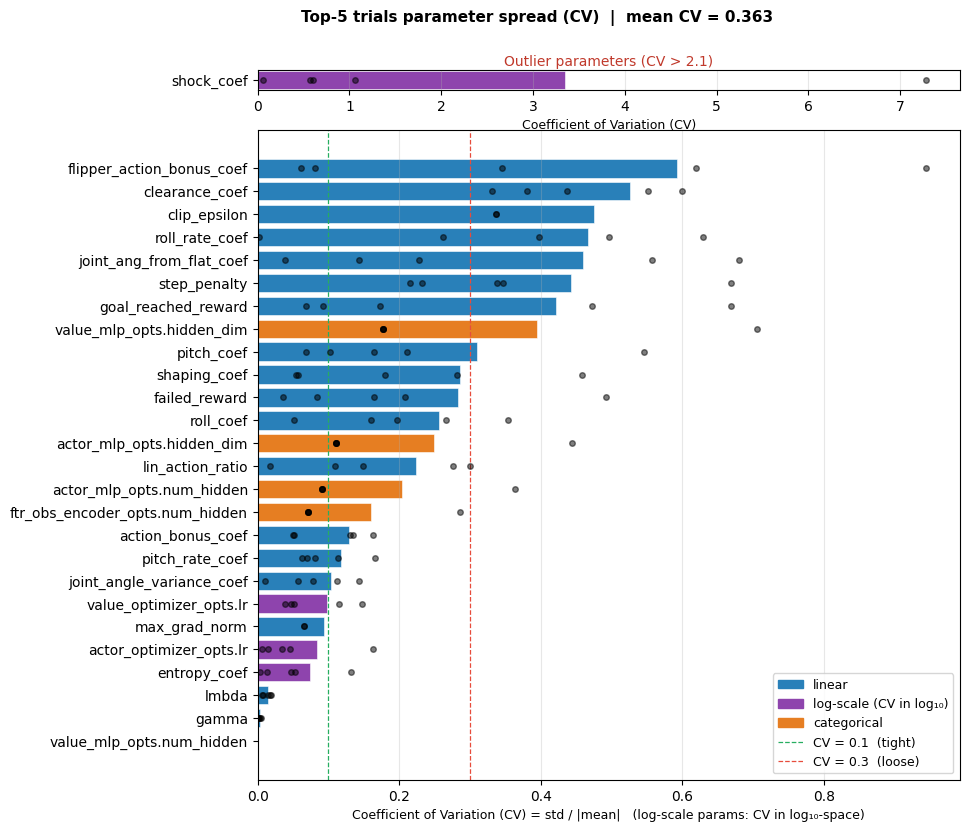

In [8]:
# ── Parameter consensus in top-N trials ───────────────────────────────────────
# For each parameter: mean, std, and normalised spread across top-N by score.
# CV  = std / |mean|          — scale-free coefficient of variation (linear params)
# CVlog = std(log10) / |mean(log10)|  — CV in log-space (log-scale params)
# 'Mean CV' summary = mean of per-parameter CVs — close to 0 means top trials agree.
TOP_N_CONSENSUS = 5

_top = df.nlargest(TOP_N_CONSENSUS, 'score')

rows = []
for p in param_names:
    vals = _top[p].dropna()
    if len(vals) == 0:
        continue
    is_cat = p in categorical_params
    is_log = p in log_params
    if is_log and (vals > 0).all():
        import math
        log_vals = vals.apply(math.log10)
        _mean_log = log_vals.mean()
        _std_log  = log_vals.std(ddof=1)
        _mean = 10 ** _mean_log
        _std  = vals.std(ddof=1)
        _var  = vals.var(ddof=1)
        _cv   = _std_log / abs(_mean_log) if _mean_log != 0 else float('nan')
        _cv_label = 'CVlog'
    else:
        _mean = vals.mean()
        _std  = vals.std(ddof=1)
        _var  = vals.var(ddof=1)
        _cv   = _std / abs(_mean) if _mean != 0 else float('nan')
        _cv_label = 'CV'
    rows.append({
        'param':    short_name(p),
        'type':     'cat' if is_cat else ('log' if is_log else 'lin'),
        'mean':     _mean,
        'std':      _std,
        'var':      _var,
        'cv':       _cv,
        'cv_label': _cv_label,
        'values':   vals.tolist(),
    })

consensus_df = pd.DataFrame(rows).sort_values('cv', ascending=False).reset_index(drop=True)
mean_cv  = consensus_df['cv'].mean()
mean_var = consensus_df['var'].mean()

print(f'Top-{TOP_N_CONSENSUS} trial consensus  (scores: {", ".join(f"{v:.4f}" for v in _top["score"].values)})')
print(f'Mean CV across all parameters : {mean_cv:.4f}  (0 = perfect agreement, 1 = std equals mean)')
print(f'Mean variance (raw)           : {mean_var:.4f}')
print()

disp = consensus_df[['param', 'type', 'mean', 'std', 'var', 'cv']].copy()
with pd.option_context('display.max_rows', None, 'display.width', 200,
                        'display.float_format', '{:.4g}'.format):
    display(disp)

# ── Bar chart: CV per parameter — split outliers into separate panel ──────────
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

# Params whose CV is far above the rest get their own panel so they don't
# compress the main axis. Threshold: median + 3 * std of CV values.
_cv_clean = consensus_df['cv'].dropna()
_outlier_thresh = _cv_clean.median() + 3 * _cv_clean.std()
outlier_df = consensus_df[consensus_df['cv'] > _outlier_thresh].copy()
normal_df  = consensus_df[consensus_df['cv'] <= _outlier_thresh].copy()

def _bar_colors(sub_df):
    return ['#e67e22' if r['type'] == 'cat' else
            '#8e44ad' if r['type'] == 'log' else '#2980b9'
            for _, r in sub_df.iterrows()]

# ── Layout constants ──────────────────────────────────────────────────────────
FIG_WIDTH = 9.0   # report column width (inches)
BAR_H     = 0.25  # axes-area height per bar (inches)

def _draw_panel(ax, sub_df, show_legend=False, show_ref_lines=True):
    ax.barh(sub_df['param'], sub_df['cv'], color=_bar_colors(sub_df),
            edgecolor='white', linewidth=0.4)
    for _, row in sub_df.iterrows():
        if row['std'] > 0:
            for v in row['values']:
                dev = abs(v - row['mean']) / row['std'] * row['cv']
                ax.plot(dev, row['param'], 'o', color='black',
                        markersize=4, alpha=0.5, zorder=5)
    if show_ref_lines:
        ax.axvline(0.1, color='#27ae60', linewidth=0.9, linestyle='--')
        ax.axvline(0.3, color='#e74c3c', linewidth=0.9, linestyle='--')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    if show_legend:
        legend_handles = [
            Patch(color='#2980b9', label='linear'),
            Patch(color='#8e44ad', label='log-scale (CV in log₁₀)'),
            Patch(color='#e67e22', label='categorical'),
            Line2D([0], [0], color='#27ae60', linewidth=0.9, linestyle='--',
                   label='CV = 0.1  (tight)'),
            Line2D([0], [0], color='#e74c3c', linewidth=0.9, linestyle='--',
                   label='CV = 0.3  (loose)'),
        ]
        ax.legend(handles=legend_handles, fontsize=9, loc='lower right')

has_outliers = len(outlier_df) > 0
if has_outliers:
    n_out  = len(outlier_df)
    n_norm = len(normal_df)

    # Axes plot-area heights in inches (just the bar rows, no labels/titles)
    h_out = max(n_out  * BAR_H, 0.5)
    h_nor = n_norm * BAR_H

    # Fixed space budgets (inches) for labels / titles that live *outside* axes
    BOT = 0.25   # below ax_nor  : x-tick labels + xlabel
    GAP = 0.4   # between panels: ax_out xlabel (bottom) + visual breathing room
    TOP = 0.35   # above ax_out  : outlier title + suptitle

    h_fig = BOT + h_nor + GAP + h_out + TOP
    L, R  = 0.19, 0.97

    fig = plt.figure(figsize=(FIG_WIDTH, h_fig))
    fy  = lambda y: y / h_fig   # inches from bottom → figure fraction

    ax_nor = fig.add_axes([L, fy(BOT),                  R-L, fy(h_nor)])
    ax_out = fig.add_axes([L, fy(BOT + h_nor + GAP),    R-L, fy(h_out-0.3)])

    _draw_panel(ax_out, outlier_df, show_legend=False, show_ref_lines=False)
    ax_out.set_title(f'Outlier parameters (CV > {_outlier_thresh:.1f})',
                     fontsize=10, color='#c0392b', pad=3)
    ax_out.set_xlabel('Coefficient of Variation (CV)', fontsize=9)

    _draw_panel(ax_nor, normal_df, show_legend=True, show_ref_lines=True)
    ax_nor.set_xlabel('Coefficient of Variation (CV) = std / |mean|   (log-scale params: CV in log₁₀-space)',
                      fontsize=9)

    # Suptitle placed in the TOP band above ax_out
    fig.text(0.5, fy(BOT + h_nor + GAP + h_out + TOP * 0.4),
             f'Top-{TOP_N_CONSENSUS} trials parameter spread (CV)  |  mean CV = {mean_cv:.3f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
else:
    BOT = 0.55; TOP = 0.45
    h_nor = len(consensus_df) * BAR_H
    h_fig = BOT + h_nor + TOP
    L, R  = 0.19, 0.97
    fig   = plt.figure(figsize=(FIG_WIDTH, h_fig))
    fy    = lambda y: y / h_fig
    ax    = fig.add_axes([L, fy(BOT), R-L, fy(h_nor)])
    _draw_panel(ax, consensus_df, show_legend=True, show_ref_lines=True)
    ax.set_xlabel('Coefficient of Variation (CV) = std / |mean|   (log-scale params: CV in log₁₀-space)',
                  fontsize=9)
    fig.text(0.5, fy(BOT + h_nor + TOP * 0.4),
             f'Top-{TOP_N_CONSENSUS} trials parameter spread (CV)  |  mean CV = {mean_cv:.3f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.savefig(fname="images/param_consensus.svg",format="svg")
plt.show()

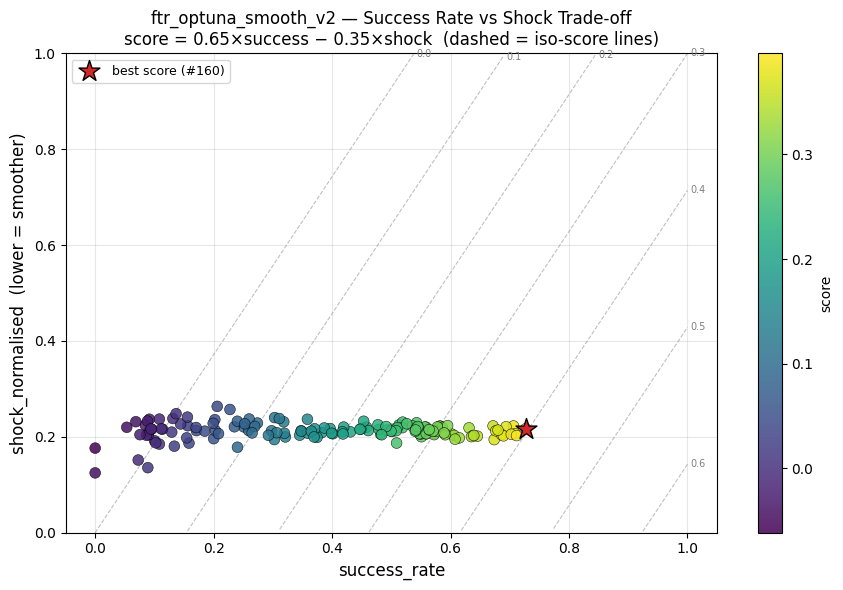

success_rate : min=0.000  max=0.727  mean=0.392
shock_norm   : min=0.125  max=0.264  mean=0.213


In [9]:
# ── Success rate vs shock trade-off ───────────────────────────────────────────
sub = df[df[[sr_col, shock_col]].notna().all(axis=1)]
if len(sub) == 0:
    print("No trials with component metrics yet — rerun once newer trials complete.")
else:
    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(
        sub[sr_col], sub[shock_col],
        c=sub["score"], cmap="viridis", s=60, edgecolors="black",
        linewidths=0.4, alpha=0.85, zorder=3
    )
    fig.colorbar(sc, ax=ax, label="score")

    # Annotate best-score trial
    best = sub.loc[sub["score"].idxmax()]
    ax.scatter(best[sr_col], best[shock_col], s=250, marker="*",
               color="#d62728", edgecolors="black", zorder=5,
               label=f"best score (#{int(best['trial'])})")

    # Fix y to data range before drawing iso-score lines (which can reach sh=1)
    y_top = sub[shock_col].max() * 1.2
    ax.set_ylim(0, 1)

    # Diagonal iso-score lines clipped to data y range
    w_sr, w_sh = METRIC_WEIGHTS[sr_col], METRIC_WEIGHTS[shock_col]
    sr_grid = np.linspace(0, 1, 200)
    for s_val in np.arange(0.0, 0.9, 0.1):
        # score = w_sr*sr + w_sh*sh  →  sh = (score - w_sr*sr) / w_sh
        sh_line = (s_val - w_sr * sr_grid) / w_sh
        mask = (sh_line >= 0) & (sh_line <= 1)
        if mask.any():
            ax.plot(sr_grid[mask], sh_line[mask], "--", linewidth=0.8,
                    color="gray", alpha=0.5)
            ax.text(sr_grid[mask][-1] + 0.005, sh_line[mask][-1],
                    f"{s_val:.1f}", fontsize=7, color="gray", va="center")

    ax.set_xlabel("success_rate", fontsize=12)
    ax.set_ylabel("shock_normalised  (lower = smoother)", fontsize=12)
    ax.set_title(f"{study_name} — Success Rate vs Shock Trade-off\n"
                 f"score = {w_sr}×success − {abs(w_sh)}×shock  (dashed = iso-score lines)",
                 fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
    print(f"success_rate : min={sub[sr_col].min():.3f}  max={sub[sr_col].max():.3f}  mean={sub[sr_col].mean():.3f}")
    print(f"shock_norm   : min={sub[shock_col].min():.3f}  max={sub[shock_col].max():.3f}  mean={sub[shock_col].mean():.3f}")

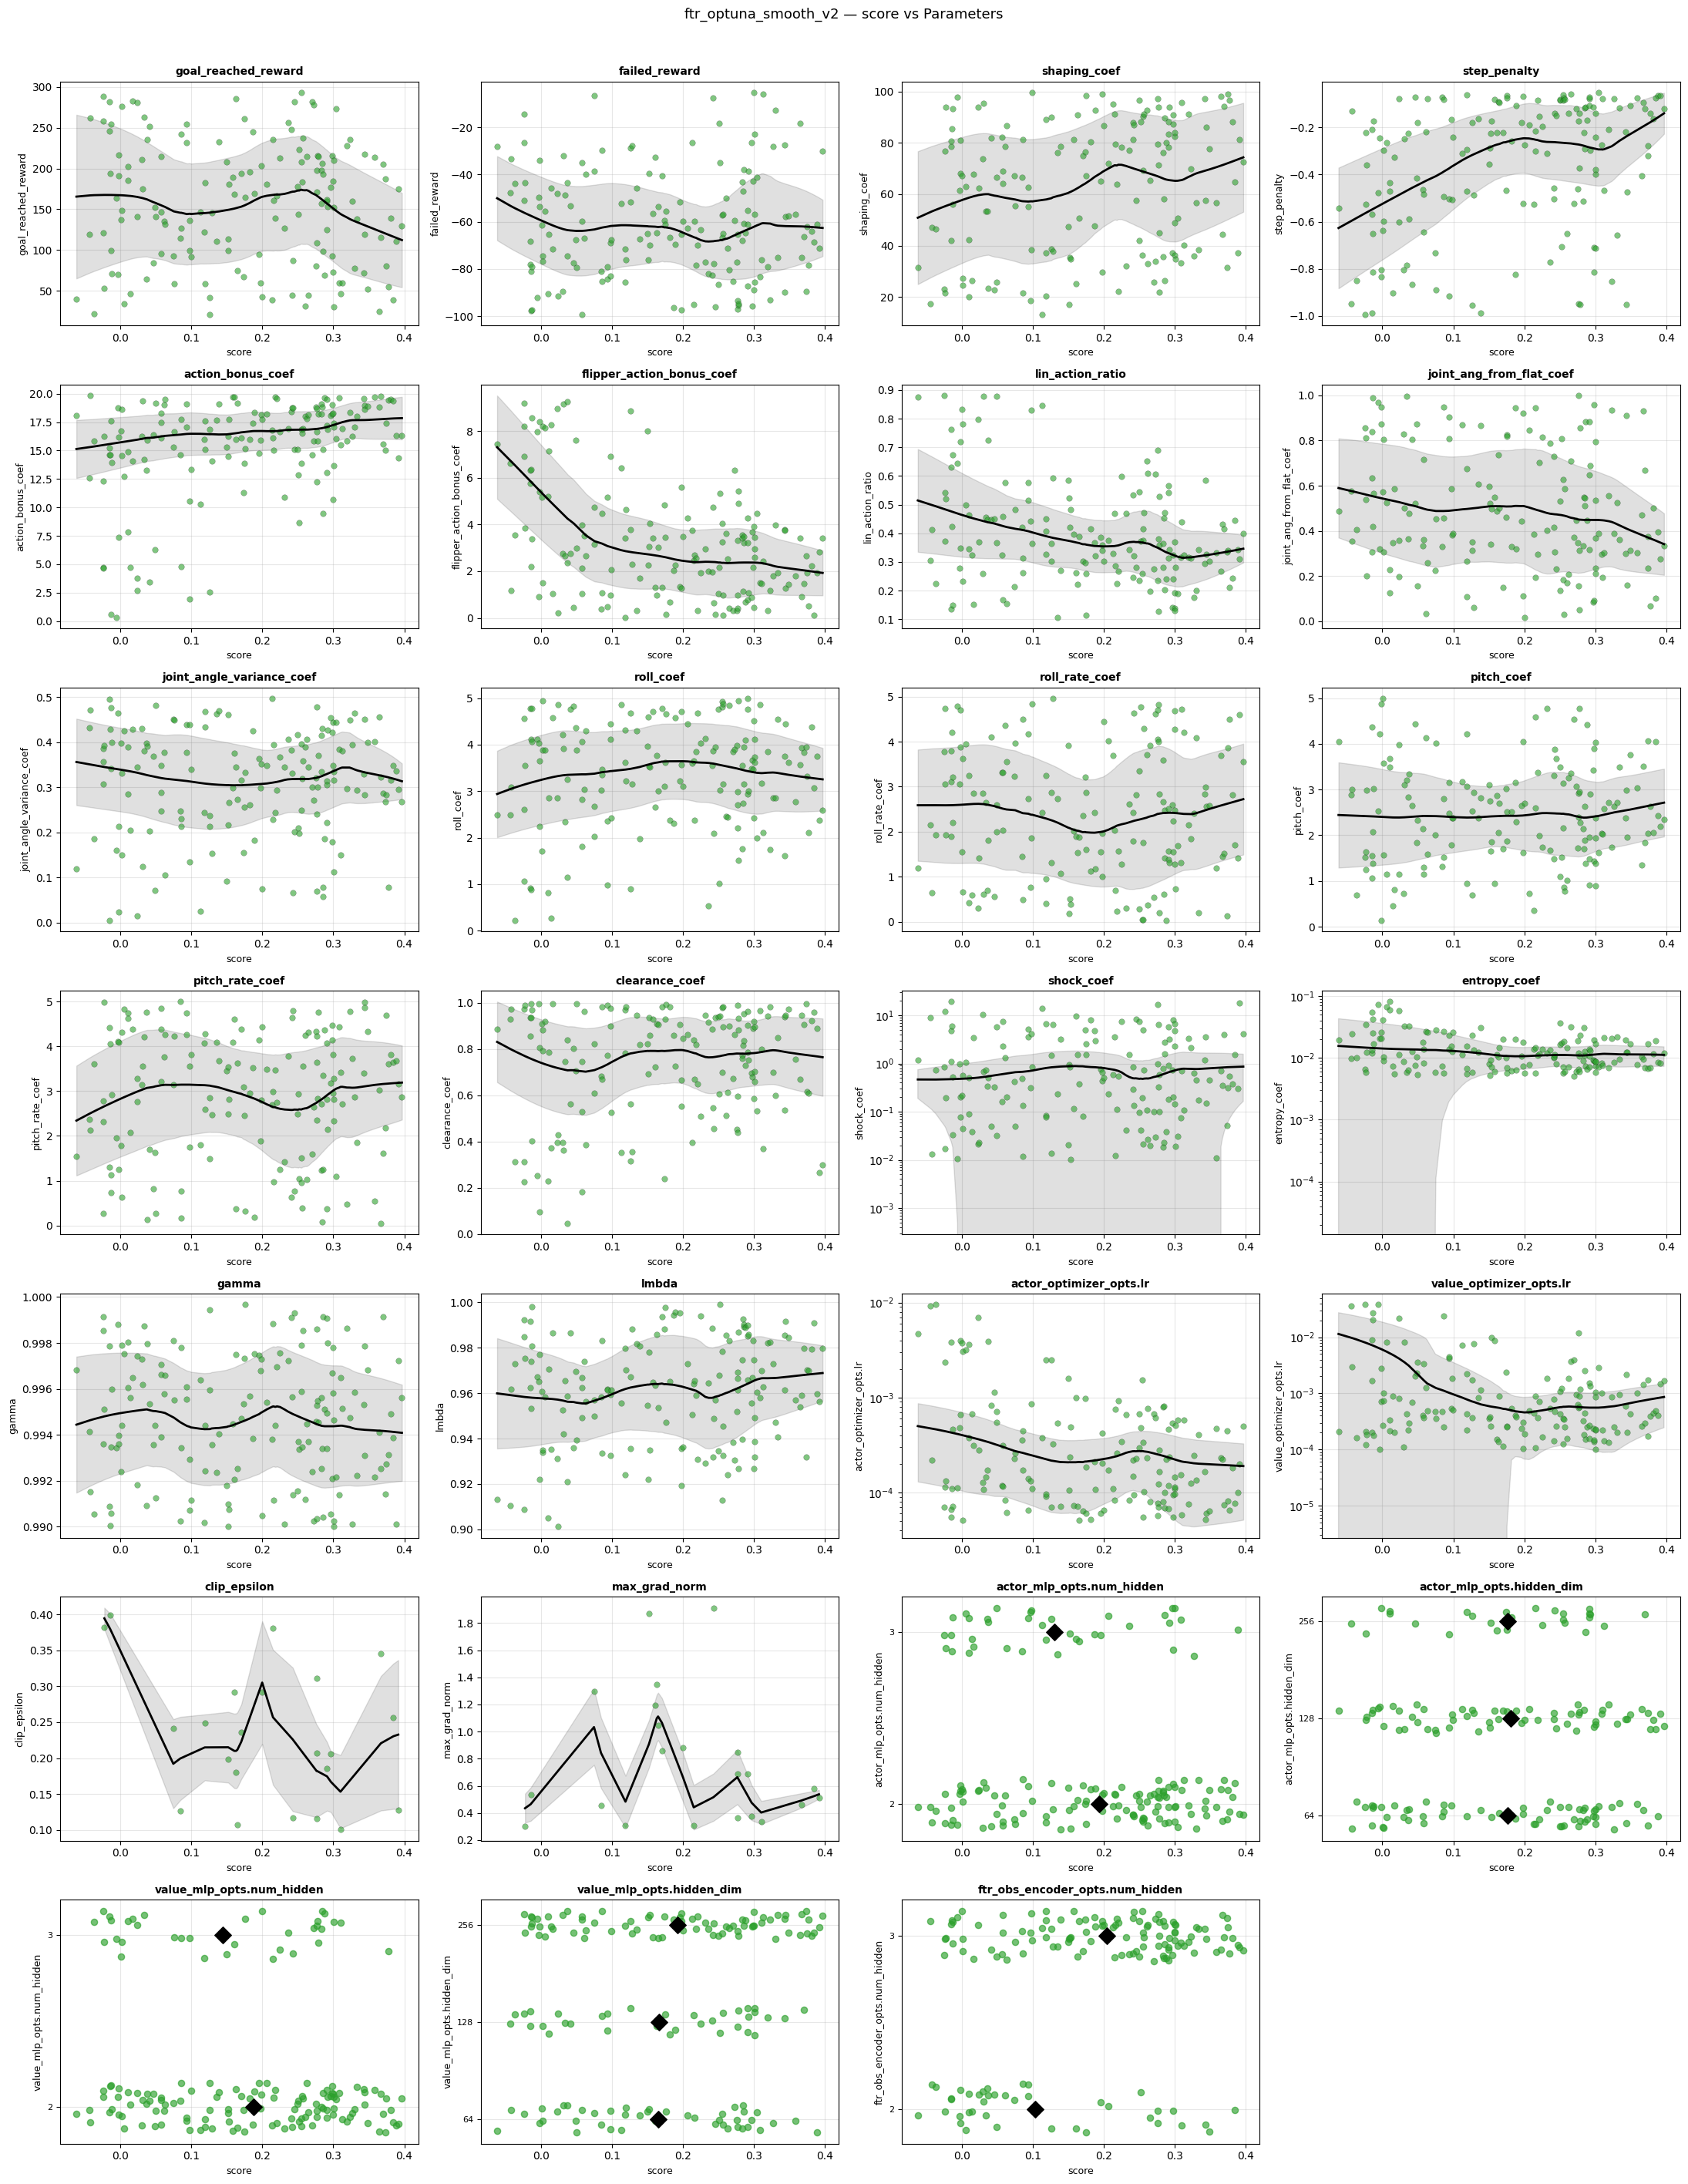

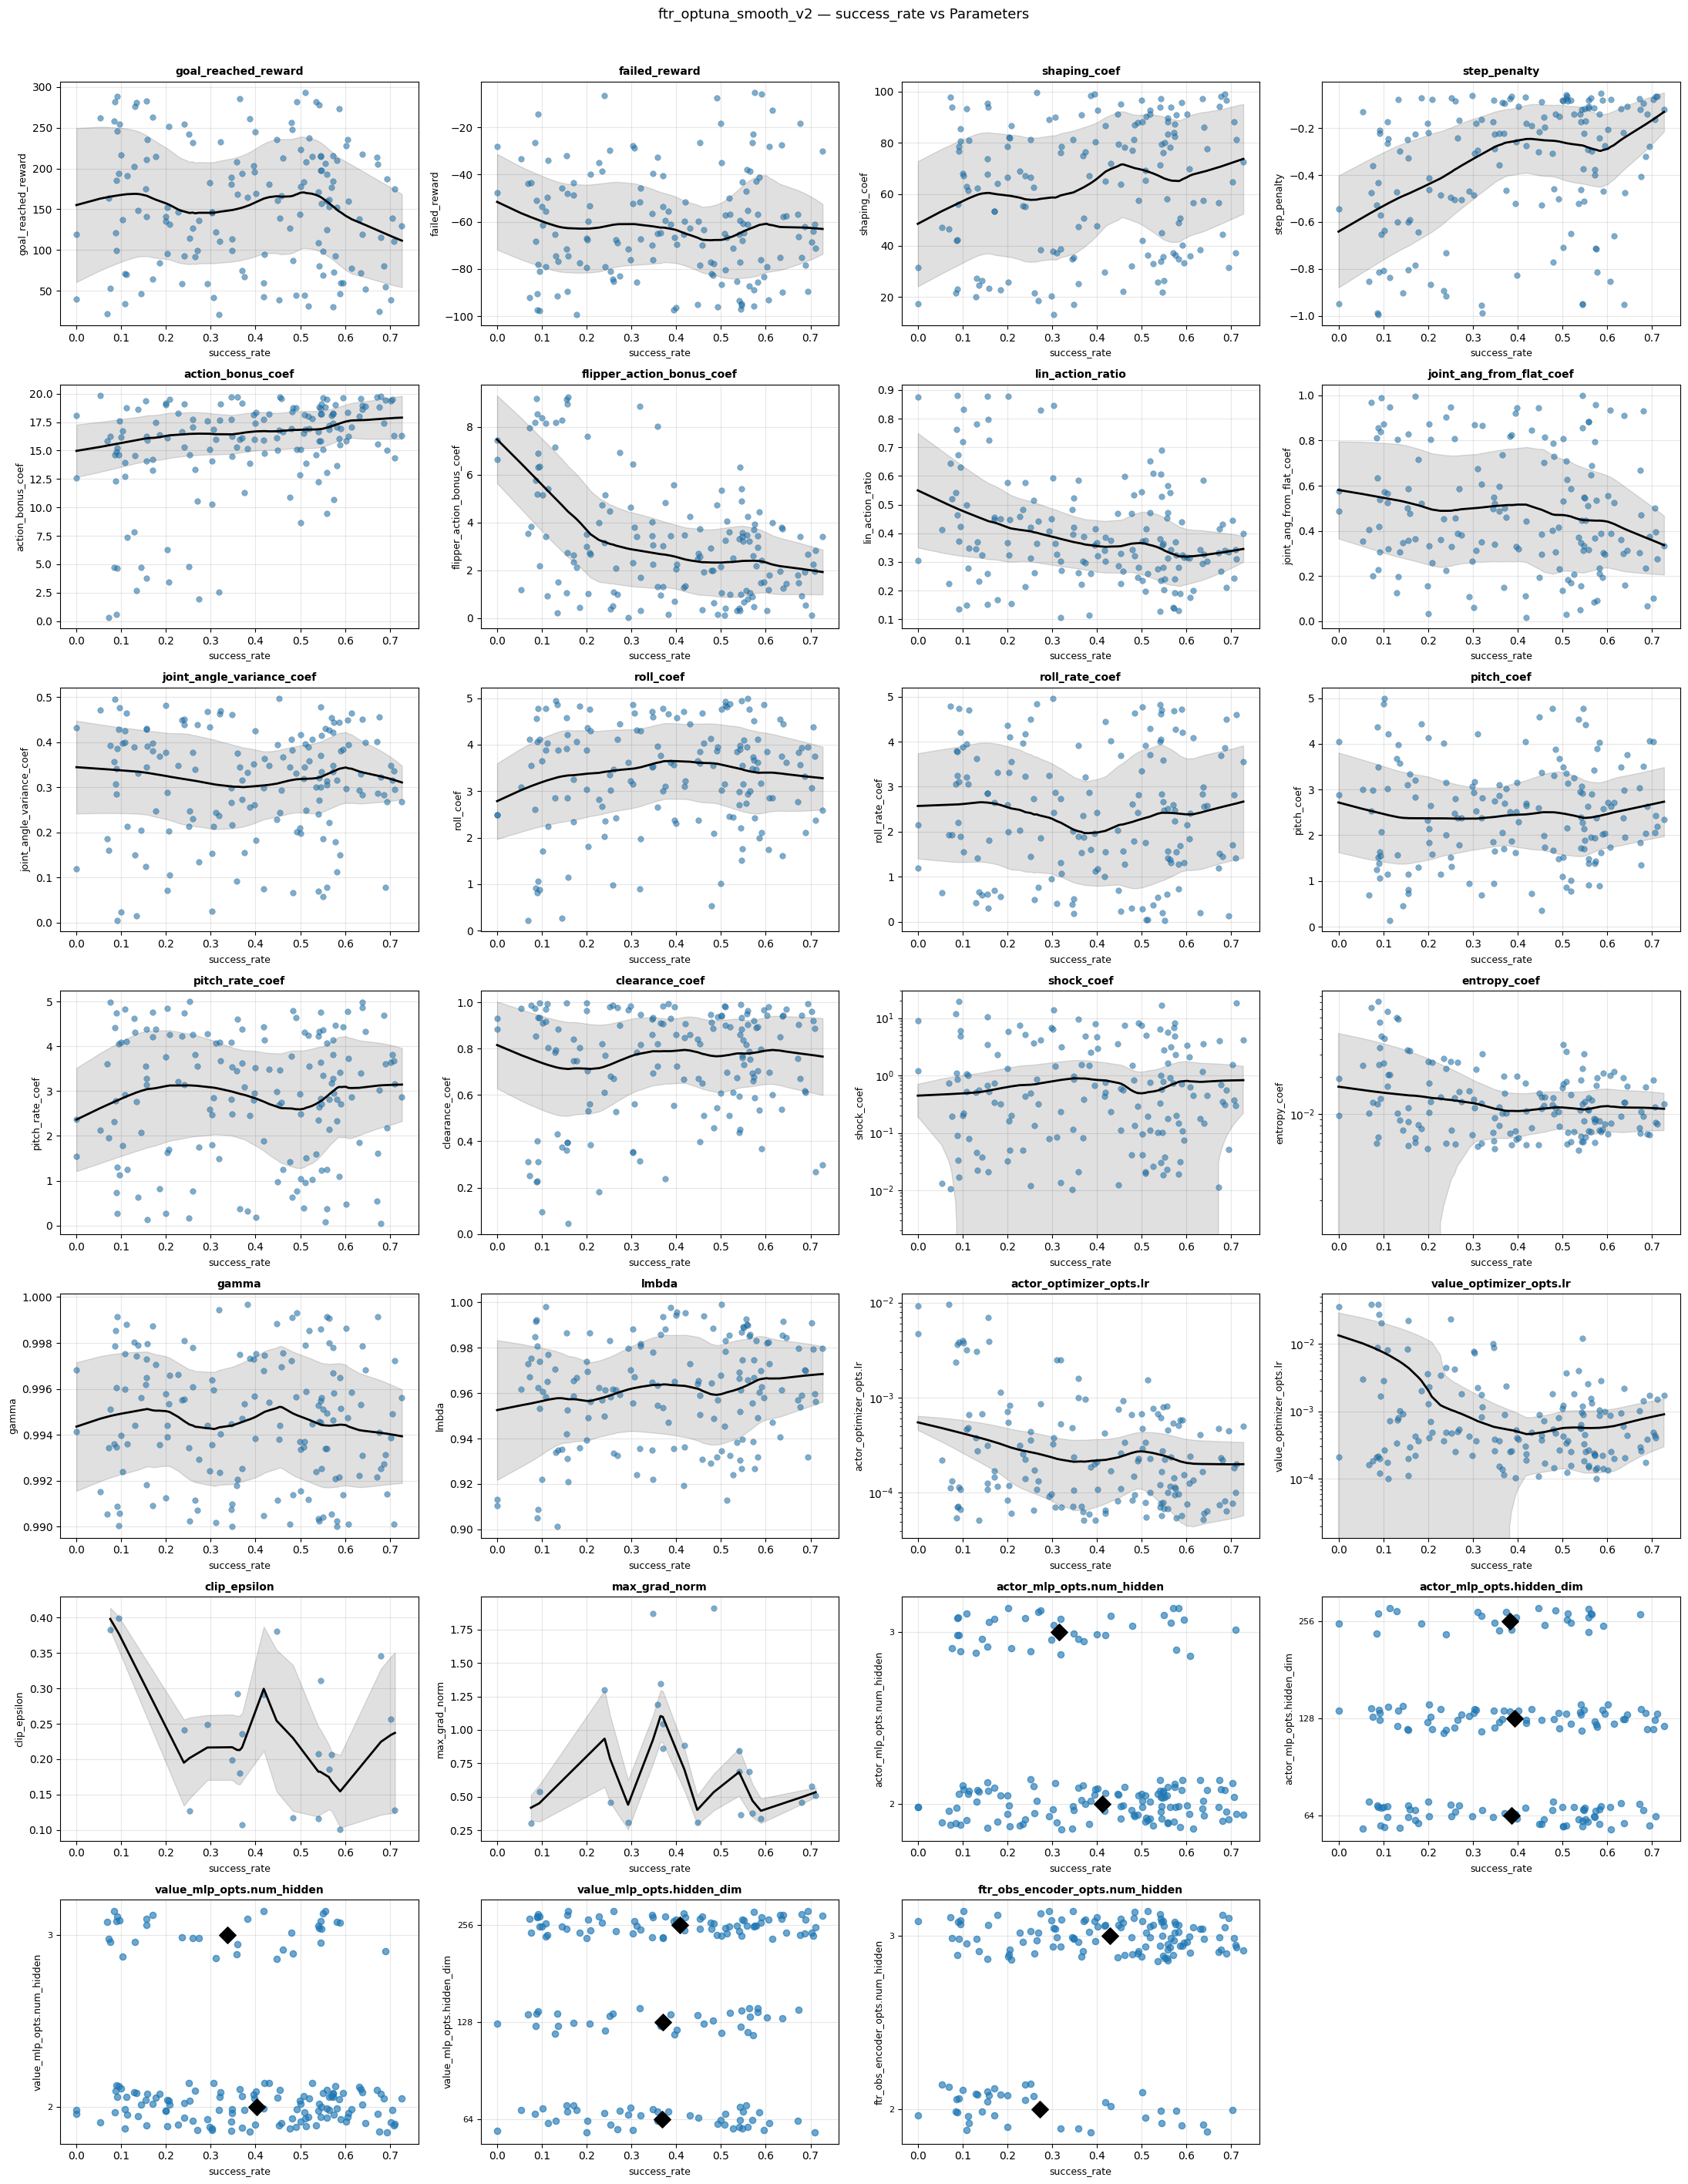

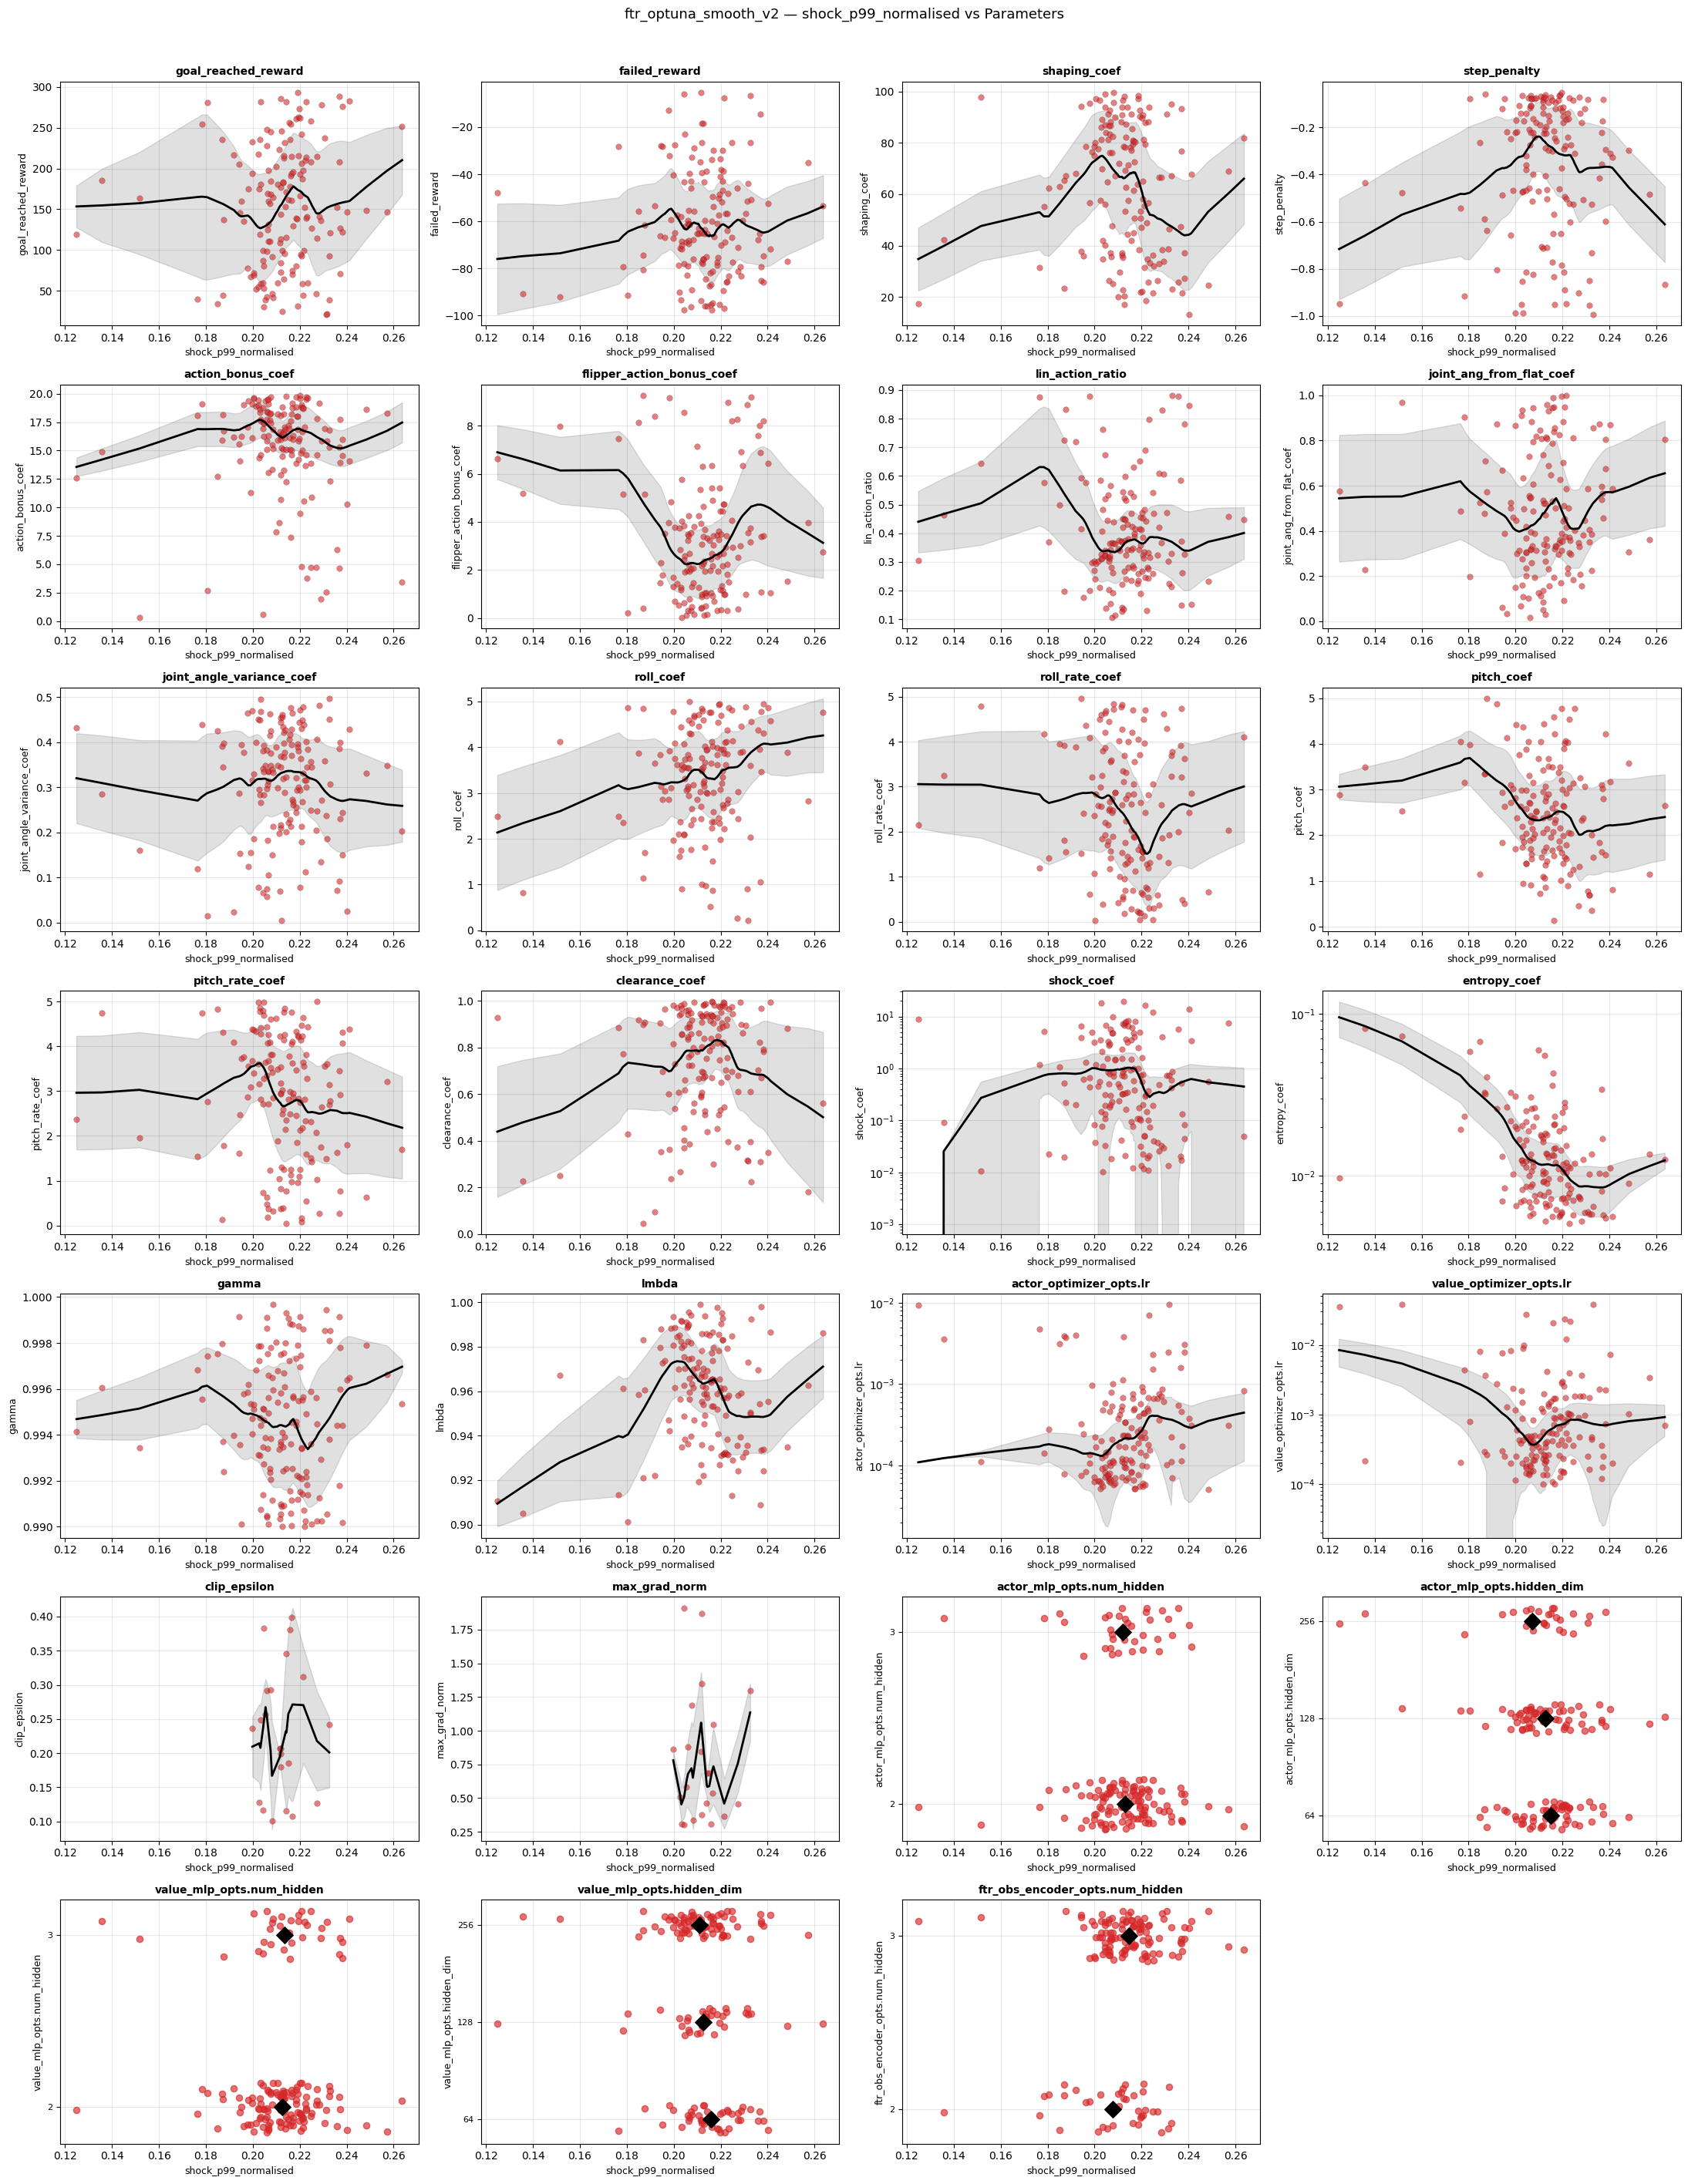

In [10]:
# ── Parameter scatter plots vs score / success_rate / shock_normalised ─────────
# metric on x-axis (auto-scaled to data), parameter value on y-axis.
from statsmodels.nonparametric.smoothers_lowess import lowess

TARGET_METRICS = [
    ("score",    df,  "#2ca02c"),
    (sr_col,     df[df[sr_col].notna()],    "#1f77b4"),
    (shock_col,  df[df[shock_col].notna()], "#d62728"),
]

all_params = continuous_params + categorical_params
ncols = 4
nrows = (len(all_params) + ncols - 1) // ncols

for metric_col, metric_df, color in TARGET_METRICS:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows))
    axes = np.atleast_2d(axes)

    for idx, param in enumerate(all_params):
        ax = axes[idx // ncols, idx % ncols]
        x  = metric_df[metric_col].values   # metric on x
        y  = metric_df[param].values         # parameter on y

        if param in categorical_params:
            categories = sorted(metric_df[param].unique())
            for i, cat in enumerate(categories):
                vals = metric_df.loc[metric_df[param] == cat, metric_col].values
                jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(vals))
                ax.scatter(vals, np.full_like(vals, i) + jitter, s=35, alpha=0.65, color=color, zorder=3)
                ax.scatter(vals.mean(), i, s=120, marker="D", color="black", zorder=5)
            ax.set_yticks(range(len(categories)))
            ax.set_yticklabels([str(c) for c in categories], fontsize=8)
        else:
            order = np.argsort(x)
            xs, ys = x[order], y[order]
            ax.scatter(xs, ys, s=30, alpha=0.6, color=color, edgecolors="black",
                       linewidths=0.2, zorder=3)
            if len(xs) >= 8:
                smooth = lowess(ys, xs, frac=0.4, return_sorted=True)
                residuals = ys - np.interp(xs, smooth[:, 0], smooth[:, 1])
                std_smooth = np.sqrt(np.maximum(
                    lowess(residuals**2, xs, frac=0.4, return_sorted=True)[:, 1], 0))
                ax.plot(smooth[:, 0], smooth[:, 1], "-", linewidth=2, color="black", zorder=5)
                ax.fill_between(smooth[:, 0], smooth[:, 1] - std_smooth, smooth[:, 1] + std_smooth,
                                color="black", alpha=0.12, zorder=2)
            if param in log_params:
                ax.set_yscale("log")

        # x-axis: data range with small padding
        x_pad = (x.max() - x.min()) * 0.05 if x.max() > x.min() else 0.05
        ax.set_xlim(x.min() - x_pad, x.max() + x_pad)

        ax.set_xlabel(metric_col.split("/")[-1], fontsize=9)
        ax.set_ylabel(short_name(param), fontsize=9)
        ax.set_title(short_name(param), fontsize=10, fontweight="bold")
        ax.grid(True, alpha=0.3)

    for idx in range(len(all_params), nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    fig.suptitle(f"{study_name} — {metric_col.split('/')[-1]} vs Parameters",
                 fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()

/tmp/ipykernel_103273/848306159.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.92, 1.0])


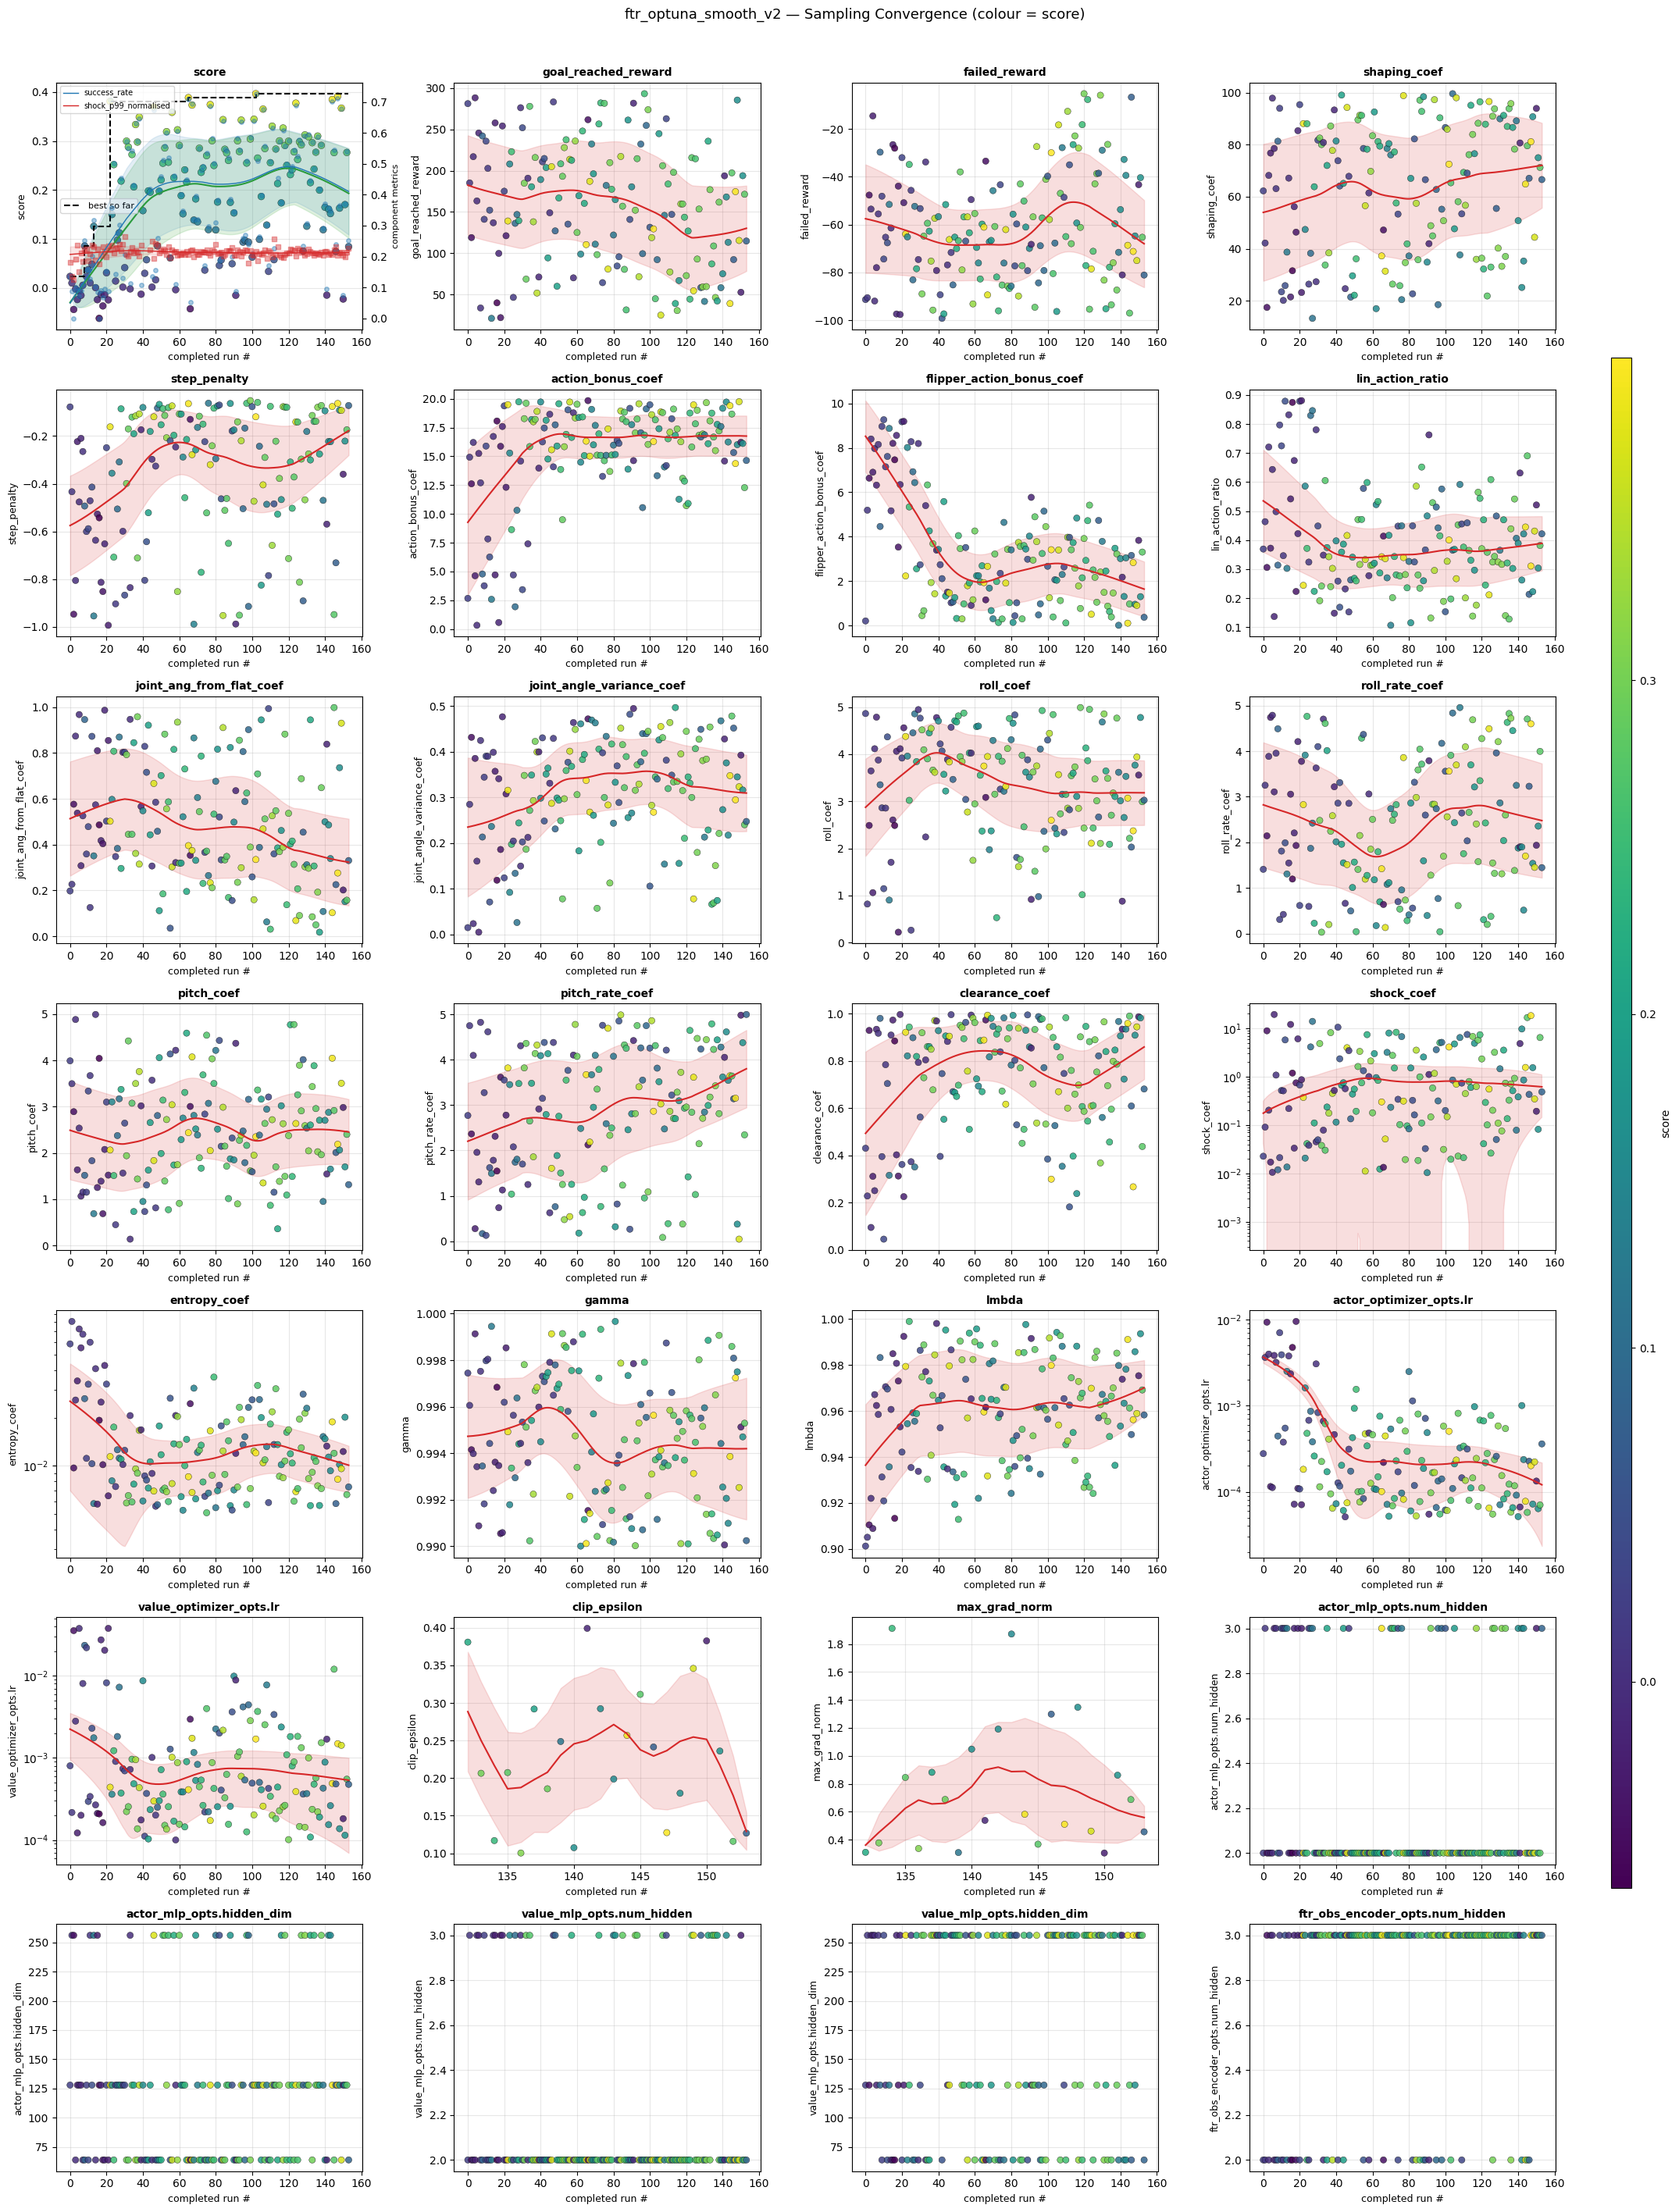

In [11]:
# ── Sampling convergence over completed-run order ─────────────────────────────
all_params = continuous_params + categorical_params
n_plots = 1 + len(all_params)
ncols   = 4
nrows   = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows))
axes = np.atleast_2d(axes)

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=df["score"].min(), vmax=df["score"].max())
run_order = np.arange(len(df), dtype=float)

def _lowess_envelope(ax, x, y, color="#d62728", frac=0.4):
    smooth = lowess(y, x, frac=frac, return_sorted=True)
    resid  = y - np.interp(x, smooth[:, 0], smooth[:, 1])
    std_s  = np.sqrt(np.maximum(lowess(resid**2, x, frac=frac, return_sorted=True)[:, 1], 0))
    ax.plot(smooth[:, 0], smooth[:, 1], "-", linewidth=1.5, color=color, zorder=5)
    ax.fill_between(smooth[:, 0], smooth[:, 1]-std_s, smooth[:, 1]+std_s,
                    color=color, alpha=0.15, zorder=2)

# Plot 0: score (+ success_rate + shock if available)
ax0 = axes[0, 0]
sc_vals = df["score"].values
ax0.scatter(run_order, sc_vals, c=sc_vals, cmap=cmap, norm=norm,
            s=40, edgecolors="black", linewidths=0.3, alpha=0.85, zorder=3)
_lowess_envelope(ax0, run_order, sc_vals, color="#2ca02c")
ax0.step(run_order, pd.Series(sc_vals).expanding().max().values,
         where="post", linewidth=1.5, color="black", linestyle="--",
         label="best so far", zorder=4)

# Overlay success_rate and shock on twin axes if available
sub = df[df[[sr_col, shock_col]].notna().all(axis=1)]
if len(sub) > 3:
    run_sub = sub.index.values.astype(float)
    ax0b = ax0.twinx()
    for comp_col, comp_color, comp_marker in [
        (sr_col,    "#1f77b4", "o"),
        (shock_col, "#d62728", "s"),
    ]:
        cv = sub[comp_col].values
        ax0b.scatter(run_sub, cv, s=16, marker=comp_marker, alpha=0.4,
                     color=comp_color, zorder=3)
        if len(run_sub) >= 8:
            sm = lowess(cv, run_sub, frac=0.4, return_sorted=True)
            resid = cv - np.interp(run_sub, sm[:, 0], sm[:, 1])
            std_s = np.sqrt(np.maximum(
                lowess(resid**2, run_sub, frac=0.4, return_sorted=True)[:, 1], 0))
            ax0b.plot(sm[:, 0], sm[:, 1], "-", linewidth=1, color=comp_color,
                      zorder=5, label=comp_col.split("/")[-1])
            ax0b.fill_between(sm[:, 0], sm[:, 1] - std_s, sm[:, 1] + std_s,
                              color=comp_color, alpha=0.12, zorder=2)
        else:
            ax0b.plot(run_sub, cv, "-", linewidth=1.2, alpha=0.7,
                      color=comp_color, label=comp_col.split("/")[-1])
    ax0b.set_ylabel("component metrics", fontsize=8)
    ax0b.legend(fontsize=7, loc="upper left")

ax0.legend(fontsize=8, loc="center left")
ax0.set_xlabel("completed run #", fontsize=9)
ax0.set_ylabel("score", fontsize=9)
ax0.set_title("score", fontsize=10, fontweight="bold")
ax0.grid(True, alpha=0.3)

# Plots 1..N: parameters
for idx, param in enumerate(all_params):
    ax = axes[(idx + 1) // ncols, (idx + 1) % ncols]
    y  = df[param].values
    ax.scatter(run_order, y, c=sc_vals, cmap=cmap, norm=norm,
               s=35, edgecolors="black", linewidths=0.3, alpha=0.85, zorder=3)
    if param not in categorical_params:
        _lowess_envelope(ax, run_order, y)
    if param in log_params:
        ax.set_yscale("log")
    ax.set_xlabel("completed run #", fontsize=9)
    ax.set_ylabel(short_name(param), fontsize=9)
    ax.set_title(short_name(param), fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3)

for idx in range(n_plots, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.012, 0.7])
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, label="score")
fig.suptitle(f"{study_name} — Sampling Convergence (colour = score)", fontsize=13, y=1.01)
fig.tight_layout(rect=[0, 0, 0.92, 1.0])
plt.savefig(fname="optuna_convergence.svg",format="svg")
plt.show()

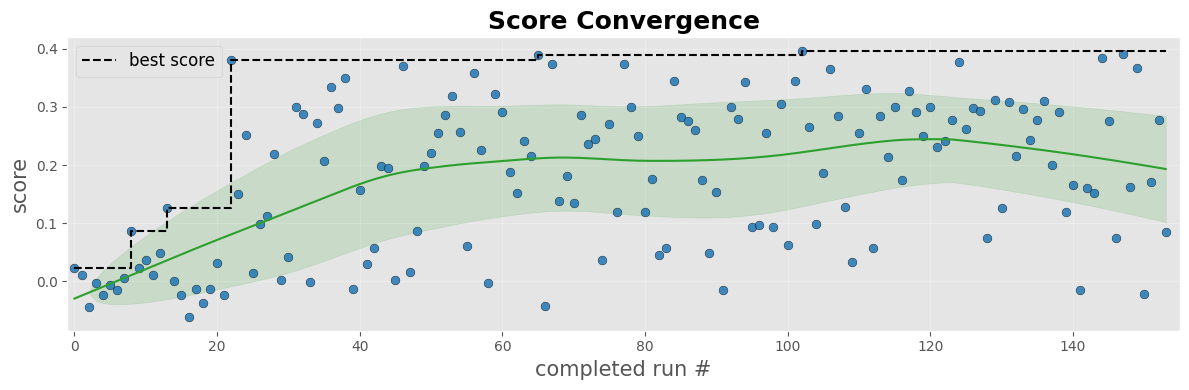

In [23]:
# ── Standalone score convergence plot ────────────────────────────────────────
fig, ax0 = plt.subplots(figsize=(12, 4))

sc_vals   = df["score"].values
run_order = np.arange(len(df), dtype=float)

ax0.scatter(run_order, sc_vals, color="#1f77b4",
            s=40, edgecolors="black", linewidths=0.3, alpha=0.85, zorder=3)
_lowess_envelope(ax0, run_order, sc_vals, color="#2ca02c")
ax0.step(run_order, pd.Series(sc_vals).expanding().max().values,
         where="post", linewidth=1.5, color="black", linestyle="--",
         label="best score", zorder=4)

ax0.legend(fontsize=12, loc="upper left")
ax0.set_xlabel("completed run #", fontsize=15)
ax0.set_ylabel("score", fontsize=15)
ax0.set_title(f"Score Convergence", fontsize=18, fontweight="bold")
ax0.grid(True, alpha=0.3)
ax0.set_xlim(left=-1,right=155)

fig.tight_layout()
plt.savefig(fname="score_convergence_optuna.svg",format="svg")
plt.show()


## Optuna Built-in Visualizations

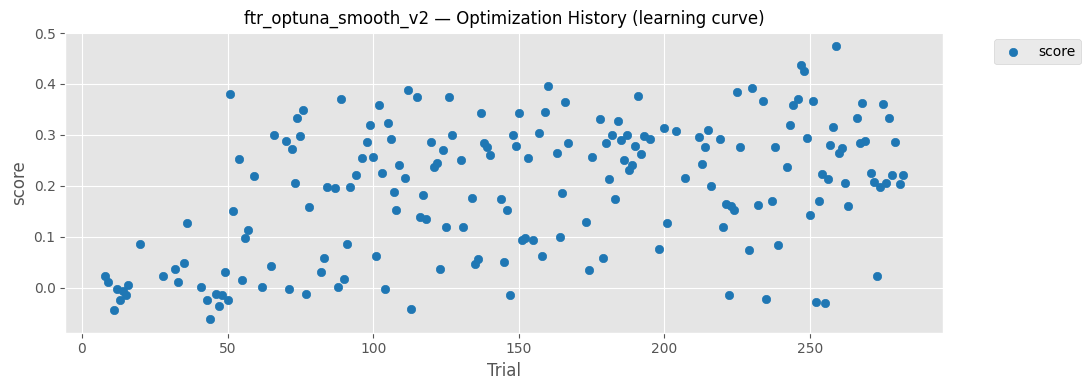

In [13]:
# ── Optimization history (learning curve) ─────────────────────────────────────
# Shows each trial's score as dots and the running best-so-far as a step line.
# A flattening curve means the sampler has converged; continued improvement
# suggests more trials would help.
import optuna.visualization.matplotlib as ovm
import warnings
warnings.filterwarnings('ignore', category=optuna.exceptions.ExperimentalWarning)

def _score(t):
    return t.values[0] if t.values else t.user_attrs.get('score', float('nan'))

ax = ovm.plot_optimization_history(study, target=_score, target_name='score')
ax.set_title(f'{study_name} — Optimization History (learning curve)', fontsize=12)
ax.figure.set_size_inches(11, 4)
ax.figure.tight_layout()
plt.show()

Note: 1 trial(s) had reversed start/end — swapped for display.
Note: 26 terminal trial(s) had no datetime_complete — skipped.


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7e1b75579c00>>
Traceback (most recent call last):
  File "/home/robot/conda/envs/isaaclab/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


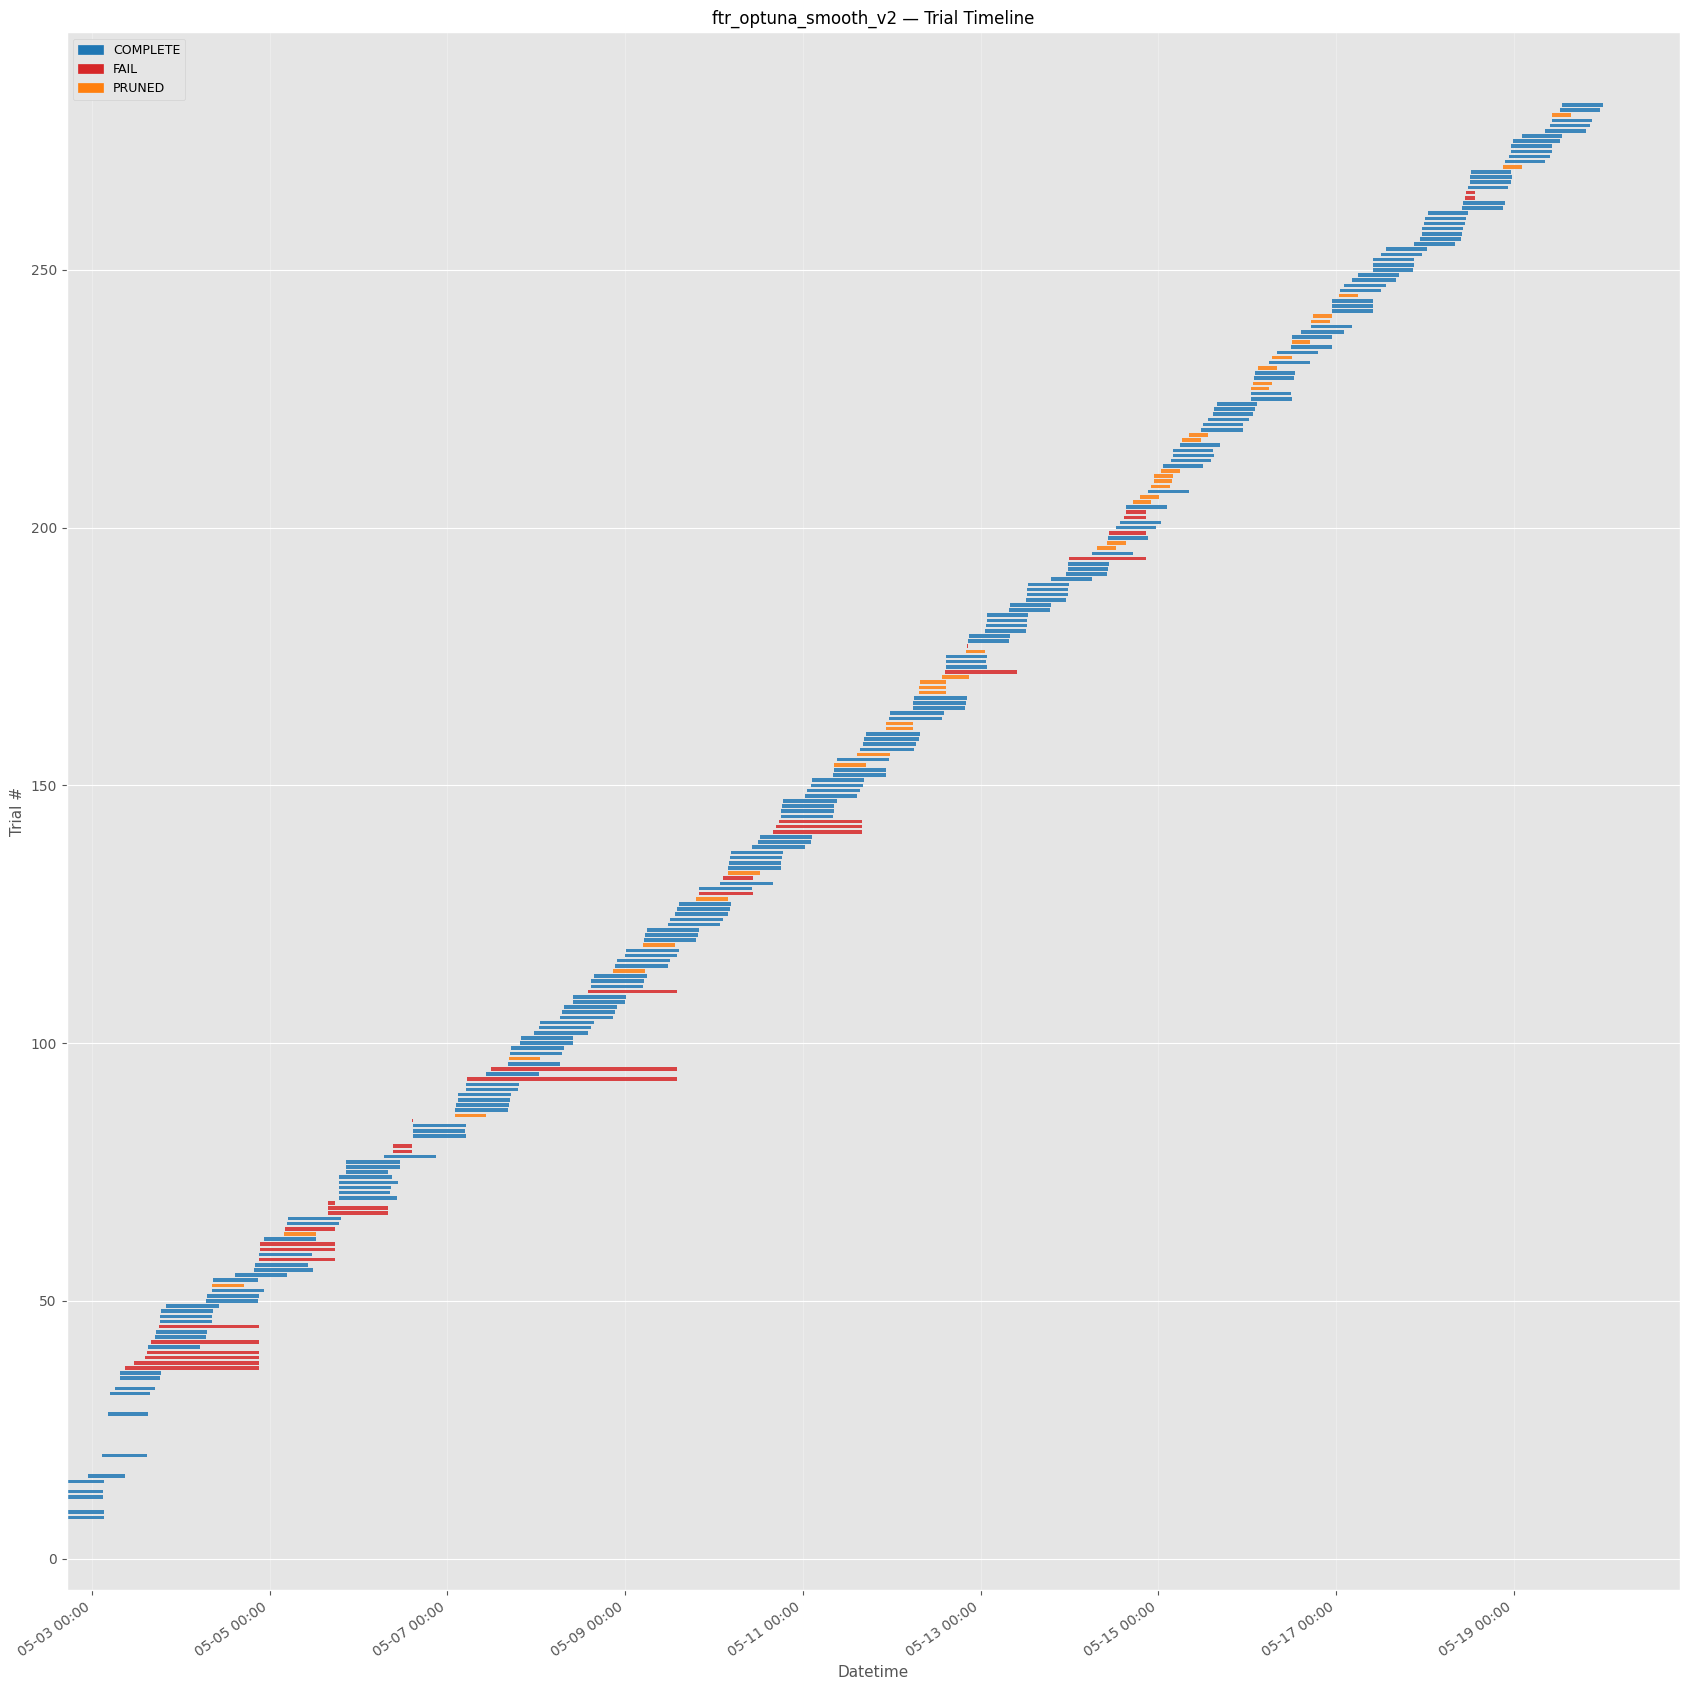

In [14]:
# ── Trial timeline ─────────────────────────────────────────────────────────────
# Custom implementation: handles reversed datetimes (SLURM clock skew) and
# formats the x-axis as readable dates instead of 00:00:00.
import matplotlib.dates as mdates
from datetime import datetime as _dt
from matplotlib.patches import Patch as _Patch

_STATE_COLORS = {
    "COMPLETE": "#1f77b4",
    "FAIL":     "#d62728",
    "PRUNED":   "#ff7f0e",
    "RUNNING":  "#2ca02c",
    "WAITING":  "#9467bd",
}
_now = _dt.now()

_tl = []
_reversed_count = 0
_skipped_count  = 0
for t in study.trials:
    if t.datetime_start is None:
        continue
    is_running = t.state.name == "RUNNING"
    if t.datetime_complete is None:
        if is_running:
            end = _now          # still active — extend bar to now
        else:
            _skipped_count += 1 # terminal with no end time → crashed, skip
            continue
    else:
        end = t.datetime_complete
    start = t.datetime_start
    if end < start:             # SLURM clock skew — swap silently
        start, end = end, start
        _reversed_count += 1
    _tl.append({"trial": t.number, "start": start, "end": end,
                 "state": t.state.name})

if _reversed_count:
    print(f"Note: {_reversed_count} trial(s) had reversed start/end — swapped for display.")
if _skipped_count:
    print(f"Note: {_skipped_count} terminal trial(s) had no datetime_complete — skipped.")

_tl.sort(key=lambda x: x["trial"])

_sz = max(6, len(_tl) // 15)
fig, ax = plt.subplots(figsize=(_sz, _sz))

for td in _tl:
    s = mdates.date2num(td["start"])
    e = mdates.date2num(td["end"])
    ax.barh(td["trial"], e - s, left=s, height=0.7,
            color=_STATE_COLORS.get(td["state"], "gray"), alpha=0.85)

ax.xaxis_date()
_all_starts = [t["start"] for t in _tl]
_all_ends   = [t["end"]   for t in _tl]
_span_days  = (max(_all_ends) - min(_all_starts)).total_seconds() / 86400
if _span_days > 1:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
else:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=35, ha="right")

legend_handles = [_Patch(color=c, label=s) for s, c in _STATE_COLORS.items()
                  if any(td["state"] == s for td in _tl)]
ax.legend(handles=legend_handles, loc="upper left", fontsize=9)
ax.set_xlabel("Datetime", fontsize=11)
ax.set_ylabel("Trial #", fontsize=11)
ax.set_title(f"{study_name} — Trial Timeline", fontsize=12)
ax.grid(True, alpha=0.3, axis="x")
fig.tight_layout()
plt.show()

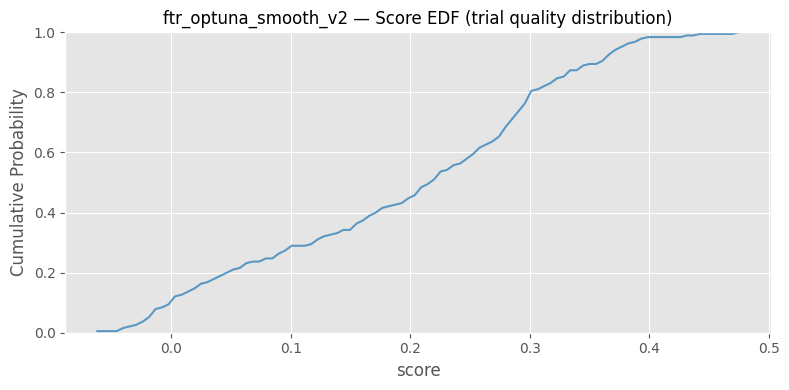

In [ ]:
# ── Empirical Distribution Function (EDF) of scores ───────────────────────────
# X = score threshold, Y = fraction of completed trials that achieved >= X.
# A steep curve shifted right means most trials scored well (efficient sampler).
# A long flat tail to the left indicates many poor trials (wide search space or
# early-phase random exploration).
ax = ovm.plot_edf(study, target=_score, target_name='score')
ax.set_title(f'{study_name} — Score EDF (trial quality distribution)', fontsize=12)
ax.figure.set_size_inches(8, 4)
ax.figure.tight_layout()
plt.show()

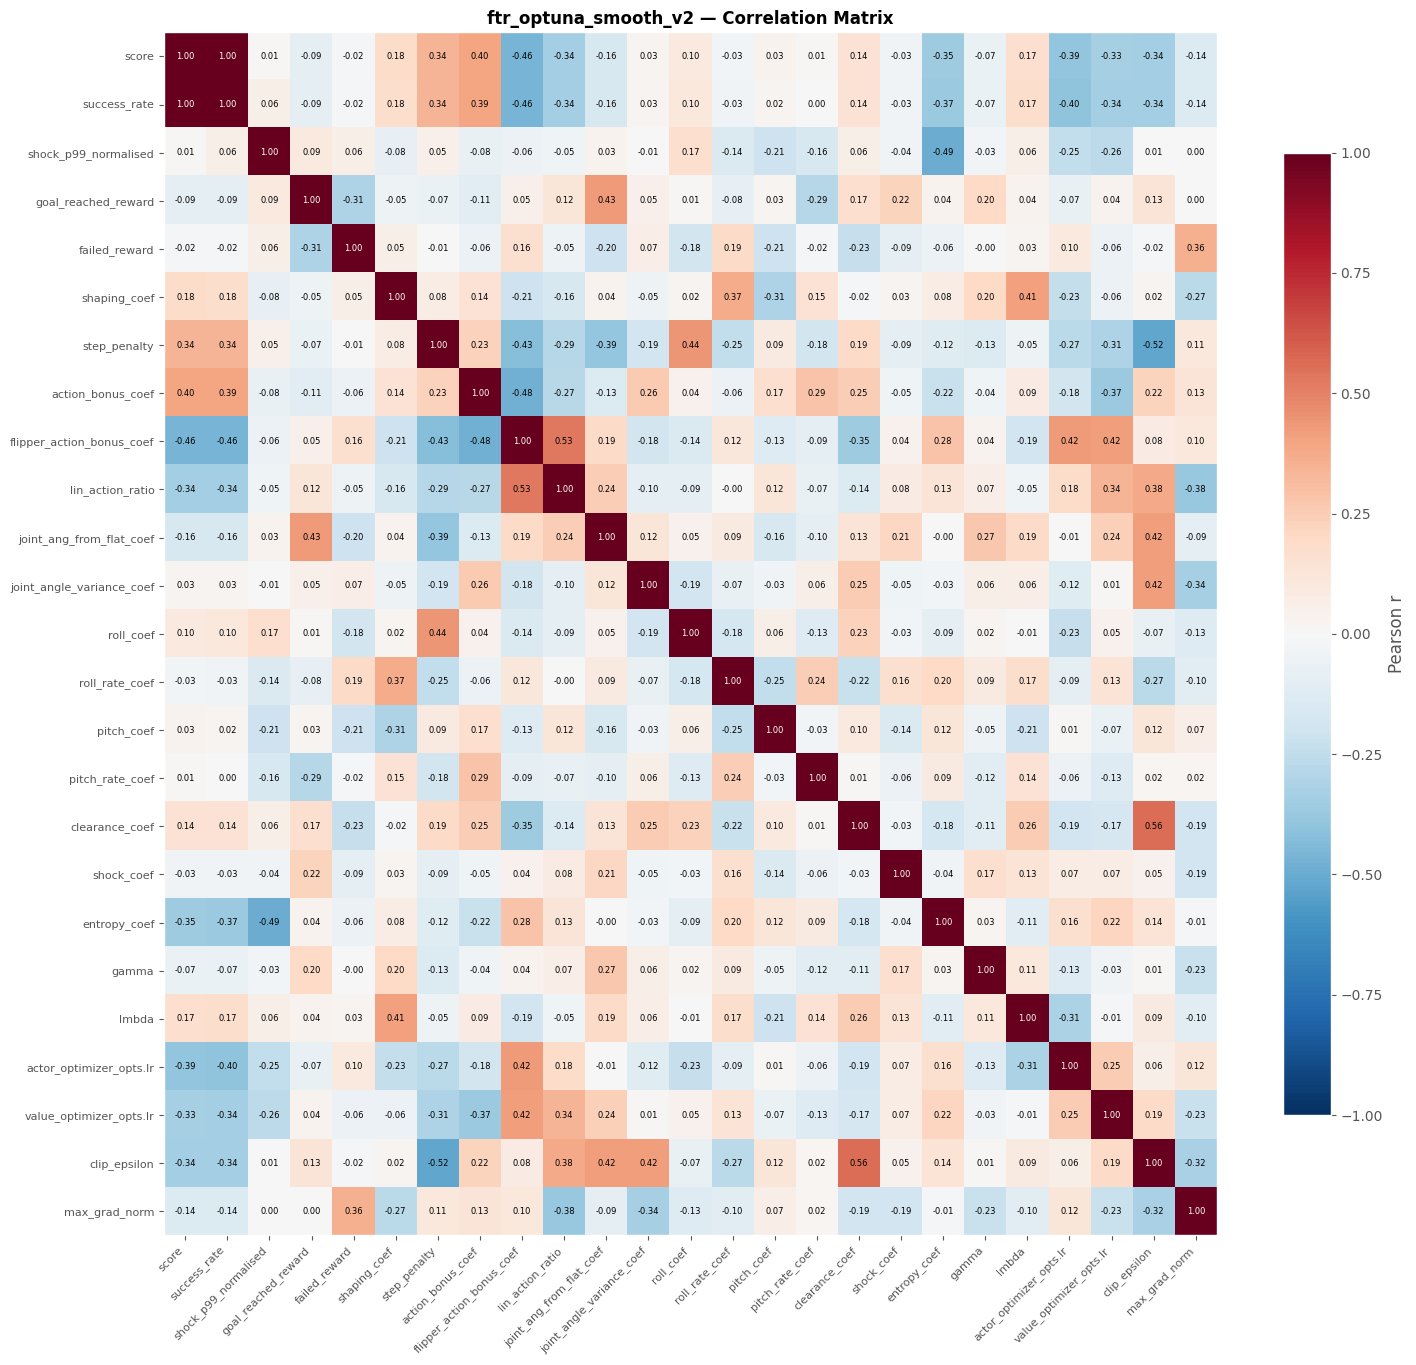


Top correlations with score:
  flipper_action_bonus_coef                     r = -0.463
  action_bonus_coef                             r = +0.398
  actor_optimizer_opts.lr                       r = -0.392
  entropy_coef                                  r = -0.352
  clip_epsilon                                  r = -0.340
  step_penalty                                  r = +0.339
  lin_action_ratio                              r = -0.338
  value_optimizer_opts.lr                       r = -0.330


In [ ]:
# ── Correlation matrix ─────────────────────────────────────────────────────────
metric_cols = [c for c in ["score", sr_col, shock_col] if df[c].notna().any()]
corr_cols   = metric_cols + [p for p in param_names if p not in categorical_params]
corr        = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(max(10, len(corr_cols)*0.6), max(8, len(corr_cols)*0.55)))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
labels = [c.split("/")[-1] if c in metric_cols else short_name(c) for c in corr_cols]
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=6, color="white" if abs(val) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title(f"{study_name} — Correlation Matrix", fontsize=12, fontweight="bold")
fig.tight_layout()
ax.grid(False)
plt.show()

print("\nTop correlations with score:")
score_corr = corr["score"].drop(metric_cols).abs().sort_values(ascending=False)
for name, val in score_corr.head(8).items():
    r = corr.loc["score", name]
    print(f"  {short_name(name):45s} r = {r:+.3f}")

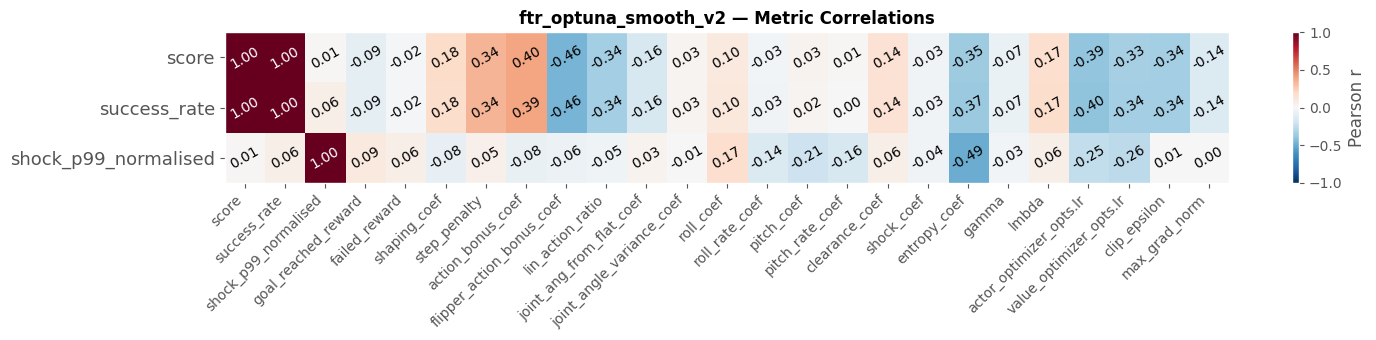

score — top param correlations:
  flipper_action_bonus_coef                     r = -0.463
  action_bonus_coef                             r = +0.398
  actor_optimizer_opts.lr                       r = -0.392
  entropy_coef                                  r = -0.352
  clip_epsilon                                  r = -0.340
  step_penalty                                  r = +0.339
  lin_action_ratio                              r = -0.338
  value_optimizer_opts.lr                       r = -0.330

success_rate — top param correlations:
  flipper_action_bonus_coef                     r = -0.465
  actor_optimizer_opts.lr                       r = -0.402
  action_bonus_coef                             r = +0.392
  entropy_coef                                  r = -0.373
  step_penalty                                  r = +0.342
  clip_epsilon                                  r = -0.342
  value_optimizer_opts.lr                       r = -0.341
  lin_action_ratio                         

In [ ]:
# ── Metric–parameter correlation (score / success_rate / shock vs all params) ──
metric_cols = [c for c in ["score", sr_col, shock_col] if df[c].notna().any()]
param_cols_corr = [p for p in param_names if p not in categorical_params]

corr_full = df[metric_cols + param_cols_corr].corr()

# Columns: metrics first (self-correlation block), then parameters
all_cols   = metric_cols + param_cols_corr
corr_sub   = corr_full.loc[metric_cols, all_cols]

row_labels = [c.split("/")[-1] for c in metric_cols]
col_labels = [c.split("/")[-1] for c in metric_cols] + [short_name(p) for p in param_cols_corr]
n_metric   = len(metric_cols)

fig, ax = plt.subplots(figsize=(max(10, len(all_cols) * 0.6), 3.5))
im = ax.imshow(corr_sub.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=13)
ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=10)
ax.grid(False)

for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        val = corr_sub.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=10, color="white" if abs(val) > 0.5 else "black",rotation=30)

# Divider between metric-metric and metric-param blocks
#ax.axvline(n_metric - 0.5, color="black", linewidth=1.5)

fig.colorbar(im, ax=ax, shrink=1, label="Pearson r")
ax.set_title(f"{study_name} — Metric Correlations",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.savefig(fname="images/optuna_correlations.svg",format="svg")
plt.show()

# Print ranked correlations for each metric (params only)
for m, label in zip(metric_cols, row_labels):
    ranked = corr_full.loc[m, param_cols_corr].abs().sort_values(ascending=False)
    print(f"{label} — top param correlations:")
    for name, val in ranked.head(8).items():
        r = corr_full.loc[m, name]
        print(f"  {short_name(name):45s} r = {r:+.3f}")
    print()


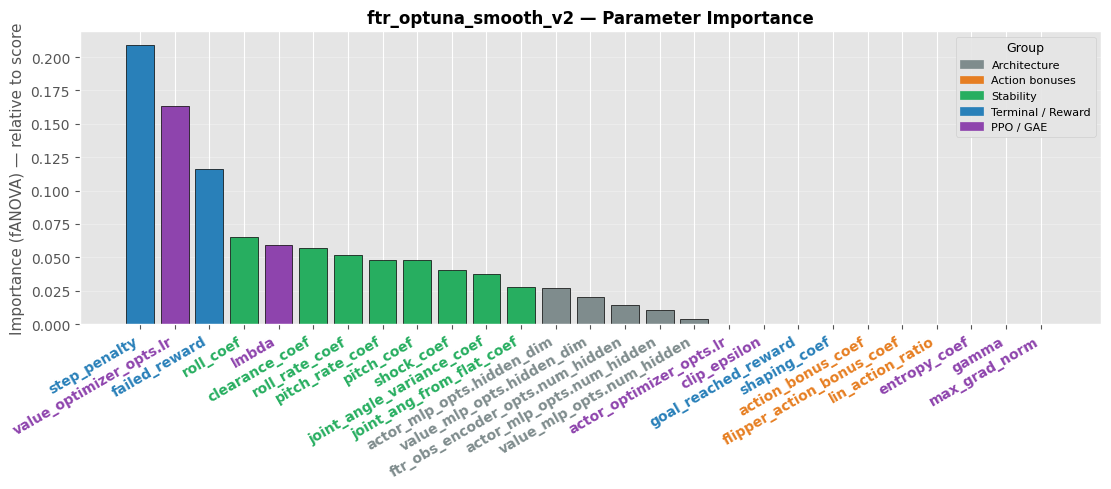


Importance ranking (score):
  step_penalty                                  0.2088
  value_optimizer_opts.lr                       0.1632
  failed_reward                                 0.1165
  roll_coef                                     0.0650
  lmbda                                         0.0592
  clearance_coef                                0.0573
  roll_rate_coef                                0.0521
  pitch_rate_coef                               0.0484
  pitch_coef                                    0.0477
  shock_coef                                    0.0406
  joint_angle_variance_coef                     0.0372
  joint_ang_from_flat_coef                      0.0275
  actor_mlp_opts.hidden_dim                     0.0270
  value_mlp_opts.hidden_dim                     0.0204
  ftr_obs_encoder_opts.num_hidden               0.0145
  actor_mlp_opts.num_hidden                     0.0108
  value_mlp_opts.num_hidden                     0.0036
  actor_optimizer_opts.lr           

In [ ]:
# ── fANOVA parameter importance ────────────────────────────────────────────────
try:
    importance = optuna.importance.get_param_importances(study)

    # Add zero-importance params (present in trials but not ranked by fANOVA)
    _all_param_keys = [k for k in param_names if k not in importance]
    _full_importance = {**importance, **{k: 0.0 for k in _all_param_keys}}

    imp_df = pd.DataFrame({
        "parameter": [short_name(k) for k in _full_importance],
        "full_key":  list(_full_importance.keys()),
        "importance": list(_full_importance.values()),
    }).sort_values("importance", ascending=True)

    # Group metadata (defined in cell-groups, always available)
    _group_order_r = _group_order

    bar_colors = [
        _group_colors.get(_group_for_full.get(row["full_key"], "Other"), "#95a5a6")
        for _, row in imp_df.iterrows()
    ]

    # Sort descending for vertical bar chart (most important on the left)
    imp_df_plot = imp_df.sort_values("importance", ascending=False).reset_index(drop=True)
    bar_colors_plot = [
        _group_colors.get(_group_for_full.get(row["full_key"], "Other"), "#95a5a6")
        for _, row in imp_df_plot.iterrows()
    ]

    fig, ax = plt.subplots(figsize=(max(10, len(imp_df_plot) * 0.42), 5))
    ax.bar(imp_df_plot["parameter"], imp_df_plot["importance"],
           color=bar_colors_plot, edgecolor="black", linewidth=0.5)

    # Rotate x-tick labels 30°, colour by group
    fig.canvas.draw()
    for tick, (_, row) in zip(ax.get_xticklabels(), imp_df_plot.iterrows()):
        gname = _group_for_full.get(row["full_key"], "Other")
        tick.set_color(_group_colors.get(gname, "#555"))
        tick.set_fontweight("bold")
        tick.set_rotation(30)
        tick.set_ha("right")

    # Group legend
    from matplotlib.patches import Patch as _Patch
    _present = [g for g in (_group_order_r or list(_group_colors))
                if any(_group_for_full.get(k) == g for k in imp_df_plot["full_key"])]
    ax.legend(handles=[_Patch(color=_group_colors.get(g, "#95a5a6"), label=g)
                        for g in _present],
              title="Group", title_fontsize=9, fontsize=8,
              loc="upper right", framealpha=0.9)

    ax.set_ylabel("Importance (fANOVA) — relative to score", fontsize=11)
    ax.set_title(f"{study_name} — Parameter Importance", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    fig.tight_layout()
    plt.show()

    print("\nImportance ranking (score):")
    for _, row in imp_df.sort_values("importance", ascending=False).iterrows():
        print(f"  {row['parameter']:45s} {row['importance']:.4f}")
except Exception as e:
    print(f"Could not compute fANOVA: {e}")
    print("(Needs >=10 complete trials and scikit-learn installed)")

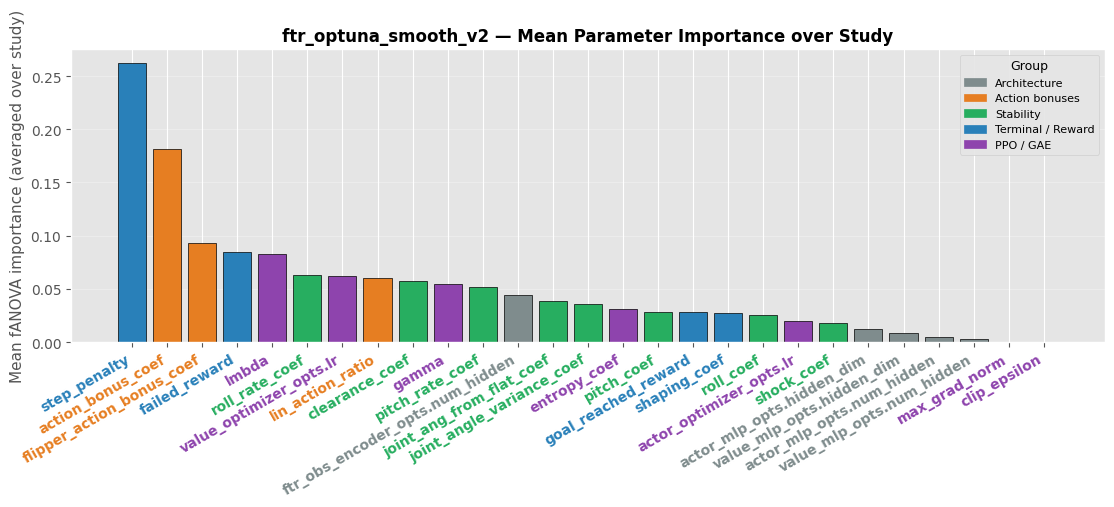

In [ ]:
# ── Mean parameter importance over study ──────────────────────────────────────
# Uses _imp_history from the importance-lines cell (run that cell first).
# Takes the mean across all checkpoints, ignoring NaN (params added mid-study).

if "_imp_history" not in globals():
    print("Run the 'Parameter Importance Evolution' cell first to populate _imp_history.")
else:
    _mean_imp = {k: float(np.nanmean(v)) for k, v in _imp_history.items()
                 if not all(np.isnan(v))}

    # Group metadata (defined in cell-groups, always available)
    _group_order_r = _group_order

    # Include zero-mean params too (appeared in history but always zero)
    _all_keys = list(_imp_history.keys())
    _mean_imp_full = {k: _mean_imp.get(k, 0.0) for k in _all_keys}

    _mean_df = pd.DataFrame({
        "full_key":   list(_mean_imp_full.keys()),
        "parameter":  [short_name(k) for k in _mean_imp_full],
        "importance": list(_mean_imp_full.values()),
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    _bar_colors_m = [
        _group_colors.get(_group_for_full.get(row["full_key"], "Other"), "#95a5a6")
        for _, row in _mean_df.iterrows()
    ]

    fig, ax = plt.subplots(figsize=(max(10, len(_mean_df) * 0.42), 5))
    ax.bar(_mean_df["parameter"], _mean_df["importance"],
           color=_bar_colors_m, edgecolor="black", linewidth=0.5)

    fig.canvas.draw()
    for tick, (_, row) in zip(ax.get_xticklabels(), _mean_df.iterrows()):
        gname = _group_for_full.get(row["full_key"], "Other")
        tick.set_color(_group_colors.get(gname, "#555"))
        tick.set_fontweight("bold")
        tick.set_rotation(30)
        tick.set_ha("right")

    from matplotlib.patches import Patch as _Patch
    _present = [g for g in (_group_order_r or list(_group_colors))
                if any(_group_for_full.get(k) == g for k in _mean_df["full_key"])]
    ax.legend(handles=[_Patch(color=_group_colors.get(g, "#95a5a6"), label=g)
                        for g in _present],
              title="Group", title_fontsize=9, fontsize=8,
              loc="upper right", framealpha=0.9)

    ax.set_ylabel("Mean fANOVA importance (averaged over study)", fontsize=11)
    ax.set_title(f"{study_name} — Mean Parameter Importance over Study", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    fig.tight_layout()
    plt.show()


## GP Surrogate Model
Fits a joint Gaussian Process over all parameters to predict `score`.
The posterior argmax is the predicted optimal configuration beyond what Optuna has sampled.

In [ ]:
# ── Fit GP on score ────────────────────────────────────────────────────────────
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from scipy.optimize import minimize

all_param_cols = continuous_params + categorical_params

# Params present in <50% of trials were added mid-study — fit separately so
# they don't shrink the main GP dataset to only trials that have them.
MID_STUDY_PARAMS = [p for p in all_param_cols if df[p].notna().mean() < 0.5]
gp_param_cols    = [p for p in all_param_cols if p not in set(MID_STUDY_PARAMS)]

if MID_STUDY_PARAMS:
    print(f"Mid-study params (separate GP): {[short_name(p) for p in MID_STUDY_PARAMS]}")

def _fit_gp(param_cols, data_df, tag=""):
    """Fit a GP on param_cols; returns (gp, X_raw, X_gp, X_min, X_range, log_mask,
    X_norm, y, best_x_norm, best_x_orig)."""
    X_raw = data_df[param_cols].values.astype(float)
    y     = data_df["score"].values
    lmask = np.array([p in log_params for p in param_cols])
    X_gp  = X_raw.copy()
    X_gp[:, lmask] = np.log(np.clip(X_gp[:, lmask], 1e-10, None))
    X_min   = X_gp.min(axis=0); X_max = X_gp.max(axis=0)
    X_range = np.where(X_max - X_min > 0, X_max - X_min, 1.0)
    X_norm  = (X_gp - X_min) / X_range
    kernel  = ConstantKernel(1.0) * RBF(length_scale=np.ones(X_norm.shape[1])) + WhiteKernel(0.01)
    gp_ = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                                    alpha=1e-6, normalize_y=True)
    gp_.fit(X_norm, y)
    print(f"{tag}GP fitted ({len(data_df)} trials x {len(param_cols)} params) — "          f"log-ML: {gp_.log_marginal_likelihood_value_:.2f}")
    # Multi-start L-BFGS-B optimum
    rng_ = np.random.default_rng(42)
    best_val, best_xn = -np.inf, None
    for _ in range(500):
        x0  = rng_.random(X_norm.shape[1])
        res = minimize(lambda x: -gp_.predict(x.reshape(1, -1))[0],
                       x0, bounds=[(0, 1)] * X_norm.shape[1], method="L-BFGS-B")
        if -res.fun > best_val:
            best_val, best_xn = -res.fun, res.x.copy()
    best_xo = best_xn * X_range + X_min
    best_xo[lmask] = np.exp(best_xo[lmask])
    for i, p in enumerate(param_cols):
        if p in categorical_params:
            cats = sorted(data_df[p].dropna().unique())
            best_xo[i] = min(cats, key=lambda c: abs(c - best_xo[i]))
    return gp_, X_raw, X_gp, X_min, X_range, lmask, X_norm, y, best_xn, best_xo

# ── Main GP — original params, all trials ─────────────────────────────────────
gp_df = df[gp_param_cols + ["score"]].dropna()
(gp, X_raw, X_gp, X_min, X_range, log_mask,
 X_norm, y_gp, best_x_norm, best_x_orig) = _fit_gp(gp_param_cols, gp_df, tag="Main ")

gp_mean, gp_std = gp.predict(best_x_norm.reshape(1, -1), return_std=True)
print(f"  Predicted optimum: {gp_mean[0]:.4f} ± {gp_std[0]:.4f}")
print(f"  Observed best    : {y_gp.max():.4f}")

# ── Secondary GP — mid-study params only, on trials that have them ─────────────
gp2 = gp2_param_cols = gp2_df = X_raw2 = X_gp2 = X_min2 = X_range2 = None
log_mask2 = X_norm2 = y_gp2 = best_x_norm2 = best_x_orig2 = None

if MID_STUDY_PARAMS:
    gp2_param_cols = MID_STUDY_PARAMS
    gp2_df = df[gp2_param_cols + ["score"]].dropna()
    if len(gp2_df) >= 5:
        (gp2, X_raw2, X_gp2, X_min2, X_range2, log_mask2,
         X_norm2, y_gp2, best_x_norm2, best_x_orig2) = _fit_gp(
             gp2_param_cols, gp2_df, tag="Secondary ")
        gp2_mean, gp2_std = gp2.predict(best_x_norm2.reshape(1, -1), return_std=True)
        print(f"  Predicted optimum: {gp2_mean[0]:.4f} ± {gp2_std[0]:.4f}")
    else:
        print(f"Secondary GP skipped — only {len(gp2_df)} trials with mid-study params.")

# ── Comparison table (main GP) ─────────────────────────────────────────────────
best_obs_idx = gp_df["score"].idxmax()
comparison = pd.DataFrame({
    "Parameter":            [short_name(p) for p in gp_param_cols],
    "GP Predicted Optimal": best_x_orig,
    "Observed Best":        gp_df.loc[best_obs_idx, gp_param_cols].values.astype(float),
})
with pd.option_context("display.max_columns", None, "display.width", 200,
                        "display.float_format", "{:.5f}".format):
    display(comparison)

if gp2 is not None:
    best_obs_idx2 = gp2_df["score"].idxmax()
    comparison2 = pd.DataFrame({
        "Parameter":            [short_name(p) for p in gp2_param_cols],
        "GP2 Predicted Optimal": best_x_orig2,
        "Observed Best":         gp2_df.loc[best_obs_idx2, gp2_param_cols].values.astype(float),
    })
    print("Secondary GP comparison:")
    with pd.option_context("display.max_columns", None, "display.width", 200,
                            "display.float_format", "{:.5f}".format):
        display(comparison2)


Mid-study params (separate GP): ['clip_epsilon', 'max_grad_norm']
Main GP fitted (154 trials x 25 params) — log-ML: -184.78


KeyboardInterrupt: 

In [ ]:
# ── MP4: Score convergence + parameter importance evolution ────────────────────────────────────────────
# CONFIG — edit these to taste
STEP            = 1    # new trial dots added per frame
IMPORTANCE_STEP = 4    # LOWESS update cadence (fANOVA only used when _imp_history is absent)
MIN_TRIALS      = 10   # minimum trials before fANOVA is attempted
FPS             = 8
LAST_FRAME_HOLD = 10.0  # seconds the final frame stays visible
MP4_PATH        = "importance_evolution.mp4"
# ──────────────────────────────────────────────────────────────────────────────

import io
import copy
import warnings
import imageio
from datetime import datetime
from matplotlib.transforms import blended_transform_factory
from PIL import Image
from IPython.display import display as ipy_display, Video as IPyVideo

# ── Resolve importance source ────────────────────────────────────────────────────
# Prefer pre-computed _imp_history / _mean_imp from the importance-lines cells.
# If not available, fall back to on-the-fly fANOVA (slow).
_have_history = "_imp_history" in globals() and "_trial_x" in globals()
_have_mean    = "_mean_imp" in globals()

if not _have_history:
    print("NOTE: _imp_history not found. Run the 'Parameter Importance Evolution' "
          "cell first to skip redundant fANOVA computation.\n"
          "Falling back to on-the-fly fANOVA (slow).")

_optuna_verb = optuna.logging.get_verbosity()
optuna.logging.set_verbosity(optuna.logging.WARNING)

_score_fn = lambda t: t.values[0] if t.values else t.user_attrs.get("score", float("nan"))

def _get_importances_subset(sub_trials):
    _now = datetime.now()
    fixed = []
    for t in sub_trials:
        if t.datetime_complete is None:
            t = copy.copy(t)
            t.datetime_complete = _now
        fixed.append(t)
    tmp = optuna.create_study(direction="maximize")
    tmp.add_trials(fixed)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return optuna.importance.get_param_importances(tmp, target=_score_fn)

# ── Build checkpoint lookup from _imp_history ────────────────────────────────────
# Maps each checkpoint trial-count to a {param: importance} dict.
if _have_history:
    _imp_at_checkpoint = {}
    for ci, cx in enumerate(_trial_x):
        _imp_at_checkpoint[int(cx)] = {
            k: (v[ci] if not np.isnan(v[ci]) else 0.0)
            for k, v in _imp_history.items()
        }
    _checkpoint_counts = sorted(_imp_at_checkpoint.keys())

    def _imp_for_n(n):
        avail = [c for c in _checkpoint_counts if c <= n]
        if not avail:
            return None
        return _imp_at_checkpoint[avail[-1]]

# ── Semantic grouping ────────────────────────────────────────────────────────────────────
_GROUPS_SPEC = [
    ("Architecture",      ["mlp_opts", "encoder_opts"]),
    ("Action bonuses",    ["action_bonus", "lin_action_ratio"]),
    ("Stability",         ["joint_ang_from_flat", "joint_angle_var",
                           "roll_coef", "roll_rate", "pitch_coef", "pitch_rate",
                           "clearance_coef", "shock_coef"]),
    ("Terminal / Reward", ["goal_reached", "failed_reward", "shaping_coef", "step_penalty"]),
    ("PPO / GAE",         ["entropy_coef", "gamma", "lmbda", "optimizer_opts",
                           "clip_epsilon", "max_grad_norm"]),
]

try:
    _final_imp   = _get_importances_subset(trials)
    _param_order = list(_final_imp.keys())
except Exception:
    _param_order = list(param_names)

def _group_of(key):
    for gname, tokens in _GROUPS_SPEC:
        if any(tok in key for tok in tokens):
            return gname
    return "Other"

_grouped: dict[str, list] = {g: [] for g, _ in _GROUPS_SPEC}
_grouped["Other"] = []
_assigned = set()
for k in _param_order:
    g = _group_of(k); _grouped[g].append(k); _assigned.add(k)
for k in param_names:
    if k not in _assigned:
        g = _group_of(k); _grouped[g].append(k); _assigned.add(k)

_group_order   = [g for g, _ in _GROUPS_SPEC] + (["Other"] if _grouped["Other"] else [])
_display_order = []
for gname in reversed(_group_order):
    for k in _grouped[gname]:
        _display_order.append((k, gname))

_separators = []
y = 0
for gname in reversed(_group_order):
    if y > 0: _separators.append(y - 0.5)
    y += len(_grouped[gname])

_group_label_y = {}
y = 0
for gname in reversed(_group_order):
    n = len(_grouped[gname])
    _group_label_y[gname] = y + (n - 1) / 2
    y += n

_colors_pool  = [plt.cm.tab20(i / 20) for i in range(20)] + \
                [plt.cm.tab20b(i / 20) for i in range(20)]
_param_colors = {k: _colors_pool[i % len(_colors_pool)]
                 for i, (k, _) in enumerate(_display_order)}

# ── Frame boundaries ──────────────────────────────────────────────────────────────
n_complete = len(df)
frame_ends = list(range(MIN_TRIALS, n_complete + 1, STEP))
if not frame_ends or frame_ends[-1] != n_complete:
    frame_ends.append(n_complete)

_cmap = plt.cm.viridis
_norm = plt.Normalize(vmin=df["score"].min(), vmax=df["score"].max())
_ylim = (df["score"].min() - 0.05, df["score"].max() + 0.05)

# ── Cache (LOWESS only during render; fANOVA only as fallback) ──────────────────────
_cache_imp      = None
_cache_smooth_x = None
_cache_smooth_y = None
_cache_smooth_s = None
_cache_comp_sm  = {}
_fallback_imps  = []   # populated only when _imp_history is absent

mp4_frames = []
print(f"Rendering {len(frame_ends)} frames  "
      f"(dots every {STEP}, LOWESS every {IMPORTANCE_STEP} trials, "
      f"{n_complete} total) ...")
if _have_history:
    print(f"Using pre-computed _imp_history ({len(_checkpoint_counts)} checkpoints) -- "
          "no fANOVA calls during render.")

for i, n in enumerate(frame_ends):
    sub_df     = df.iloc[:n]
    run_order  = np.arange(n, dtype=float)
    sc_vals    = sub_df["score"].values
    trial_nums = set(sub_df["trial"].values)

    is_last_frame   = (i == len(frame_ends) - 1)
    is_update_frame = (i == 0) or is_last_frame or (i % IMPORTANCE_STEP == 0)

    if is_update_frame:
        if n >= 8:
            _sm = lowess(sc_vals, run_order, frac=0.4, return_sorted=True)
            _resid = sc_vals - np.interp(run_order, _sm[:, 0], _sm[:, 1])
            _std_s = np.sqrt(np.maximum(
                lowess(_resid**2, run_order, frac=0.4, return_sorted=True)[:, 1], 0))
            _cache_smooth_x = _sm[:, 0]
            _cache_smooth_y = _sm[:, 1]
            _cache_smooth_s = _std_s

        comp_sub = sub_df[sub_df[[sr_col, shock_col]].notna().all(axis=1)]
        if len(comp_sub) >= 8:
            run_sub = comp_sub.index.values.astype(float)
            _cache_comp_sm = {}
            for _col in [sr_col, shock_col]:
                cv  = comp_sub[_col].values
                _sm = lowess(cv, run_sub, frac=0.4, return_sorted=True)
                _r  = cv - np.interp(run_sub, _sm[:, 0], _sm[:, 1])
                _ss = np.sqrt(np.maximum(
                    lowess(_r**2, run_sub, frac=0.4, return_sorted=True)[:, 1], 0))
                _cache_comp_sm[_col] = (_sm[:, 0], _sm[:, 1], _ss, run_sub,
                                        comp_sub[_col].values)

        # fANOVA fallback only when _imp_history is absent
        if not _have_history and n >= MIN_TRIALS:
            sub_trials_frame = [t for t in trials if t.number in trial_nums]
            try:
                _cache_imp = _get_importances_subset(sub_trials_frame)
                _fallback_imps.append(_cache_imp)
            except Exception:
                pass

    # Resolve what importance to show this frame
    if is_last_frame:
        if _have_mean:
            _display_imp = _mean_imp
            _imp_title   = "Mean parameter importance  (averaged over study)"
        elif _have_history:
            _all_keys    = list(_imp_history.keys())
            _display_imp = {k: float(np.nanmean(_imp_history[k])) for k in _all_keys}
            _imp_title   = f"Mean parameter importance  [{len(_checkpoint_counts)} checkpoints]"
        elif _fallback_imps:
            _all_keys    = list(dict.fromkeys(k for d in _fallback_imps for k in d))
            _display_imp = {k: float(np.mean([d.get(k, 0.0) for d in _fallback_imps]))
                            for k in _all_keys}
            _imp_title   = f"Mean parameter importance  [{len(_fallback_imps)} windows]"
        else:
            _display_imp = _cache_imp
            _imp_title   = f"Parameter importance  [as of trial {n}]"
    elif _have_history:
        _display_imp = _imp_for_n(n)
        _last_cp     = max((c for c in _checkpoint_counts if c <= n), default=n)
        _imp_title   = f"Parameter importance  [as of trial {_last_cp}]"
    else:
        _display_imp = _cache_imp
        _imp_title   = f"Parameter importance  [as of trial {frame_ends[max(0,i-(i%IMPORTANCE_STEP))]}]"

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(
        f"{study_name}  ·  completed trials: {n} / {n_complete}"
        + ("  [LOWESS updated]" if is_update_frame else ""),
        fontsize=12, fontweight="bold",
    )

    ax_l.scatter(run_order, sc_vals, c=sc_vals, cmap=_cmap, norm=_norm,
                 s=40, edgecolors="black", linewidths=0.3, alpha=0.85, zorder=3)
    ax_l.step(run_order, pd.Series(sc_vals).expanding().max().values,
              where="post", linewidth=1.5, color="black", linestyle="--",
              label="best score so far", zorder=4)

    if _cache_smooth_x is not None and len(_cache_smooth_x) <= n:
        ax_l.plot(_cache_smooth_x, _cache_smooth_y, "-", linewidth=1.5,
                  color="#2ca02c", zorder=5)
        ax_l.fill_between(_cache_smooth_x,
                          _cache_smooth_y - _cache_smooth_s,
                          _cache_smooth_y + _cache_smooth_s,
                          color="#2ca02c", alpha=0.15, zorder=2)

    if _cache_comp_sm:
        ax_lb = ax_l.twinx()
        comp_sub = sub_df[sub_df[[sr_col, shock_col]].notna().all(axis=1)]
        run_sub  = comp_sub.index.values.astype(float)
        for _col, _color, _marker in [(sr_col, "#1f77b4", "o"), (shock_col, "#d62728", "s")]:
            cv = comp_sub[_col].values
            ax_lb.scatter(run_sub, cv, s=16, marker=_marker, alpha=0.4,
                          color=_color, zorder=3)
            if _col in _cache_comp_sm:
                smx, smy, sms, _, _ = _cache_comp_sm[_col]
                ax_lb.plot(smx, smy, "-", linewidth=1, color=_color, zorder=5,
                           label=_col.split("/")[-1])
                ax_lb.fill_between(smx, smy - sms, smy + sms,
                                   color=_color, alpha=0.12, zorder=2)
        ax_lb.set_ylabel("success rate (blue) · shock_p99_norm (red)", fontsize=8)
        ax_lb.legend(fontsize=7, loc="upper left")

    ax_l.legend(fontsize=8, loc="lower right")
    ax_l.set_xlabel("completed run #", fontsize=10)
    ax_l.set_ylabel("score (green)", fontsize=10, color="#2ca02c")
    ax_l.set_title("Score convergence", fontsize=11, fontweight="bold")
    ax_l.set_xlim(-1, n_complete)
    ax_l.set_ylim(*_ylim)
    ax_l.grid(True, alpha=0.3)

    if _display_imp is not None:
        imp_vals   = [_display_imp.get(k, 0.0) for k, _ in _display_order]
        bar_colors = [_param_colors[k]          for k, _ in _display_order]
        y_pos      = list(range(len(_display_order)))
        ax_r.barh(y_pos, imp_vals, color=bar_colors, edgecolor="black", linewidth=0.5)
        ax_r.set_yticks(y_pos)
        ax_r.set_yticklabels([short_name(k) for k, _ in _display_order])
        for tick_obj, (k, _) in zip(ax_r.get_yticklabels(), _display_order):
            tick_obj.set_color(_param_colors[k]); tick_obj.set_fontweight("bold")
        for sep_y in _separators:
            ax_r.axhline(sep_y, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
        trans = blended_transform_factory(ax_r.transAxes, ax_r.transData)
        for gname, cy in _group_label_y.items():
            if _grouped[gname]:
                ax_r.text(1.02, cy, gname, transform=trans,
                          ha="left", va="center", fontsize=7,
                          color="gray", fontweight="bold")
        ax_r.set_xlim(0, 1)
        ax_r.set_xlabel("Importance (fANOVA)", fontsize=10)
        ax_r.set_title(_imp_title, fontsize=11, fontweight="bold")
        ax_r.grid(True, alpha=0.3, axis="x")
    else:
        ax_r.text(0.5, 0.5, f"fANOVA pending\n(< {MIN_TRIALS} trials)",
                  ha="center", va="center", transform=ax_r.transAxes, fontsize=9)
        ax_r.set_title("Parameter importance", fontsize=11, fontweight="bold")

    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    mp4_frames.append(np.array(Image.open(buf).convert("RGB")))
    buf.close()

    if (i + 1) % 10 == 0 or (i + 1) == len(frame_ends):
        print(f"  frame {i + 1:3d}/{len(frame_ends)} -- up to trial {n}", flush=True)

optuna.logging.set_verbosity(_optuna_verb)

# Repeat last frame to simulate hold
_hold_frames = max(1, int(LAST_FRAME_HOLD * FPS))
mp4_frames.extend([mp4_frames[-1]] * (_hold_frames - 1))

with imageio.get_writer(MP4_PATH, fps=FPS, codec="libx264",
                        output_params=["-pix_fmt", "yuv420p"]) as _writer:
    for _frame in mp4_frames:
        _writer.append_data(_frame)

_src = ("_mean_imp" if _have_mean else
        f"mean of _imp_history ({len(_checkpoint_counts)} checkpoints)" if _have_history else
        f"{len(_fallback_imps)} accumulated windows")
print(f"\nSaved {len(mp4_frames)}-frame MP4 -> {MP4_PATH}  "
      f"({FPS} fps, step={STEP}, last frame holds {LAST_FRAME_HOLD:.0f}s, "
      f"final frame importance: {_src})")
ipy_display(IPyVideo(MP4_PATH, embed=True))


Rendering 145 frames  (dots every 1, LOWESS every 4 trials, 154 total) ...
Using pre-computed _imp_history (37 checkpoints) -- no fANOVA calls during render.
  frame  10/145 -- up to trial 19
  frame  20/145 -- up to trial 29
  frame  30/145 -- up to trial 39
  frame  40/145 -- up to trial 49
  frame  50/145 -- up to trial 59
  frame  60/145 -- up to trial 69
  frame  70/145 -- up to trial 79
  frame  80/145 -- up to trial 89
  frame  90/145 -- up to trial 99
  frame 100/145 -- up to trial 109
  frame 110/145 -- up to trial 119
  frame 120/145 -- up to trial 129
  frame 130/145 -- up to trial 139
  frame 140/145 -- up to trial 149
  frame 145/145 -- up to trial 154


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1589, 691) to (1600, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
Multiple -pix_fmt options specified for stream 0, only the last option '-pix_fmt yuv420p' will be used.



Saved 224-frame MP4 -> importance_evolution.mp4  (8 fps, step=1, last frame holds 10s, final frame importance: _mean_imp)


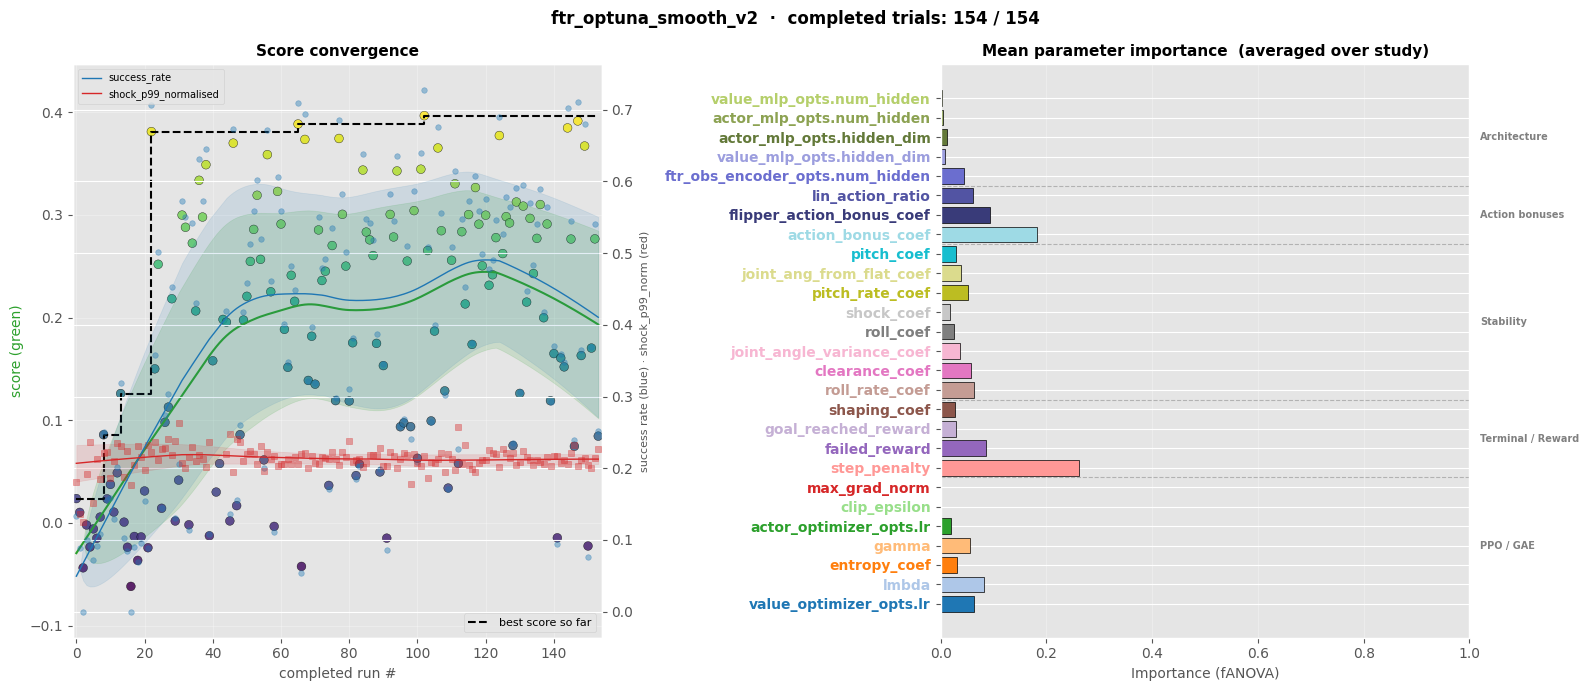

Saved importance_final_frame.png and importance_final_frame.svg


In [ ]:
# ── Export final frame (mean importance) as PNG + SVG ──────────────────────────────────────────────
import io
from matplotlib.transforms import blended_transform_factory

# Resolve mean importance (same logic as the MP4 cell)
if "_mean_imp" in globals():
    _exp_imp   = _mean_imp
    _exp_title = "Mean parameter importance  (averaged over study)"
elif "_imp_history" in globals():
    _all_keys  = list(_imp_history.keys())
    _exp_imp   = {k: float(np.nanmean(_imp_history[k])) for k in _all_keys}
    _exp_title = f"Mean parameter importance  [{len(_checkpoint_counts)} checkpoints]"
else:
    raise RuntimeError("Run the 'Parameter Importance Evolution' cell first.")

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    f"{study_name}  ·  completed trials: {len(df)} / {len(df)}",
    fontsize=12, fontweight="bold",
)

# Left: full score trace
run_order = np.arange(len(df), dtype=float)
sc_vals   = df["score"].values
_cmap2 = plt.cm.viridis
_norm2 = plt.Normalize(vmin=sc_vals.min(), vmax=sc_vals.max())
ax_l.scatter(run_order, sc_vals, c=sc_vals, cmap=_cmap2, norm=_norm2,
             s=40, edgecolors="black", linewidths=0.3, alpha=0.85, zorder=3)
ax_l.step(run_order, pd.Series(sc_vals).expanding().max().values,
          where="post", linewidth=1.5, color="black", linestyle="--",
          label="best score so far", zorder=4)
if _cache_smooth_x is not None:
    ax_l.plot(_cache_smooth_x, _cache_smooth_y, "-", linewidth=1.5, color="#2ca02c", zorder=5)
    ax_l.fill_between(_cache_smooth_x,
                      _cache_smooth_y - _cache_smooth_s,
                      _cache_smooth_y + _cache_smooth_s,
                      color="#2ca02c", alpha=0.15, zorder=2)
if _cache_comp_sm:
    ax_lb = ax_l.twinx()
    comp_sub = df[df[[sr_col, shock_col]].notna().all(axis=1)]
    run_sub  = comp_sub.index.values.astype(float)
    for _col, _color, _marker in [(sr_col, "#1f77b4", "o"), (shock_col, "#d62728", "s")]:
        cv = comp_sub[_col].values
        ax_lb.scatter(run_sub, cv, s=16, marker=_marker, alpha=0.4, color=_color, zorder=3)
        if _col in _cache_comp_sm:
            smx, smy, sms, _, _ = _cache_comp_sm[_col]
            ax_lb.plot(smx, smy, "-", linewidth=1, color=_color, zorder=5,
                       label=_col.split("/")[-1])
            ax_lb.fill_between(smx, smy - sms, smy + sms, color=_color, alpha=0.12, zorder=2)
    ax_lb.set_ylabel("success rate (blue) · shock_p99_norm (red)", fontsize=8)
    ax_lb.legend(fontsize=7, loc="upper left")
ax_l.legend(fontsize=8, loc="lower right")
ax_l.set_xlabel("completed run #", fontsize=10)
ax_l.set_ylabel("score (green)", fontsize=10, color="#2ca02c")
ax_l.set_title("Score convergence", fontsize=11, fontweight="bold")
ax_l.set_xlim(-1, len(df))
ax_l.set_ylim(sc_vals.min() - 0.05, sc_vals.max() + 0.05)
ax_l.grid(True, alpha=0.3)

# Right: mean importance bars
imp_vals   = [_exp_imp.get(k, 0.0) for k, _ in _display_order]
bar_colors = [_param_colors[k]      for k, _ in _display_order]
y_pos      = list(range(len(_display_order)))
ax_r.barh(y_pos, imp_vals, color=bar_colors, edgecolor="black", linewidth=0.5)
ax_r.set_yticks(y_pos)
ax_r.set_yticklabels([short_name(k) for k, _ in _display_order])
for tick_obj, (k, _) in zip(ax_r.get_yticklabels(), _display_order):
    tick_obj.set_color(_param_colors[k]); tick_obj.set_fontweight("bold")
for sep_y in _separators:
    ax_r.axhline(sep_y, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
trans = blended_transform_factory(ax_r.transAxes, ax_r.transData)
for gname, cy in _group_label_y.items():
    if _grouped[gname]:
        ax_r.text(1.02, cy, gname, transform=trans,
                  ha="left", va="center", fontsize=7, color="gray", fontweight="bold")
ax_r.set_xlim(0, 1)
ax_r.set_xlabel("Importance (fANOVA)", fontsize=10)
ax_r.set_title(_exp_title, fontsize=11, fontweight="bold")
ax_r.grid(True, alpha=0.3, axis="x")

fig.tight_layout()
fig.savefig("importance_final_frame.png", dpi=150, bbox_inches="tight")
fig.savefig("importance_final_frame.svg", format="svg", bbox_inches="tight")
plt.show()
print("Saved importance_final_frame.png and importance_final_frame.svg")


Computing fANOVA at 37 checkpoints …
Done.


/tmp/ipykernel_936018/770497826.py:45: RuntimeWarning: All-NaN slice encountered
  if np.nanmax(y_vals) < 1e-6:


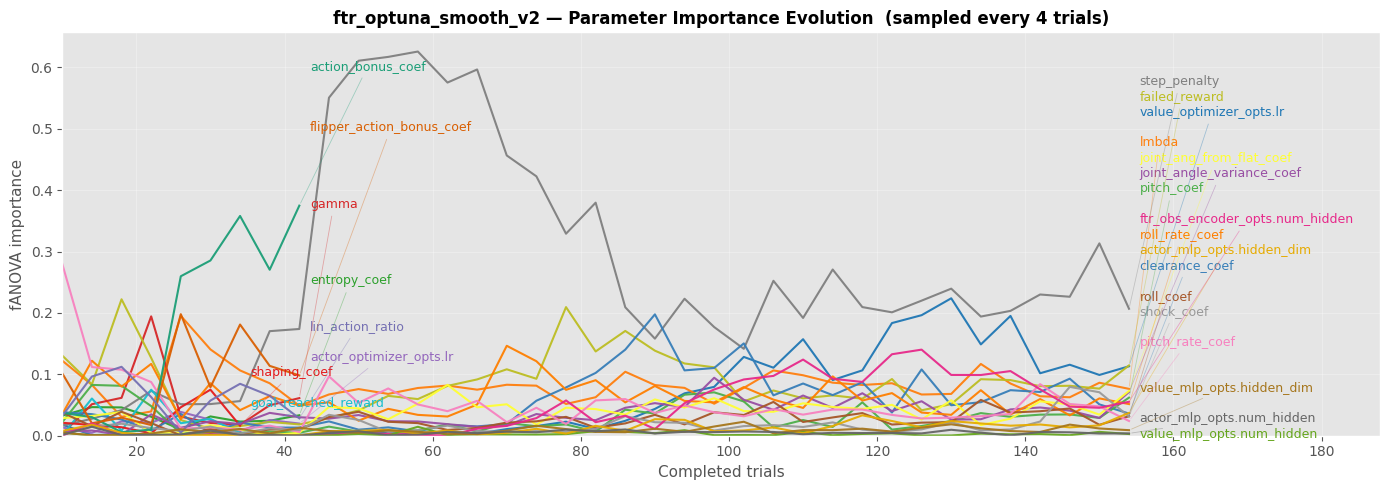

In [ ]:
# ── Parameter importance evolution — line chart ────────────────────────────────
# Reuses _display_order, _param_colors, _grouped, _group_label_y, _separators,
# IMPORTANCE_STEP, MIN_TRIALS, and _get_importances_subset from the GIF cell.

_checkpoints = list(range(MIN_TRIALS, len(df) + 1, IMPORTANCE_STEP))
if not _checkpoints or _checkpoints[-1] != len(df):
    _checkpoints.append(len(df))

# Collect importance at each checkpoint
_imp_history = {k: [] for k, _ in _display_order}
_trial_x     = []

print(f"Computing fANOVA at {len(_checkpoints)} checkpoints …", flush=True)
for _n in _checkpoints:
    _sub_df   = df.iloc[:_n]
    _tnums    = set(_sub_df["trial"].values)
    _sub_tri  = [t for t in trials if t.number in _tnums]
    try:
        _imp = _get_importances_subset(_sub_tri)
    except Exception:
        _imp = {}
    for k, _ in _display_order:
        _imp_history[k].append(_imp.get(k, float("nan")))
    _trial_x.append(_n)
print("Done.")

_trial_x = np.array(_trial_x)

# ── High-contrast colour palette (overrides pastel GIF colours) ───────────────
_hc_pool = (
    [plt.cm.tab10(i / 10)   for i in range(10)] +
    [plt.cm.Set1(i / 9)     for i in range(9)]  +
    [plt.cm.Dark2(i / 8)    for i in range(8)]
)
_line_colors = {k: _hc_pool[i % len(_hc_pool)]
                for i, (k, _) in enumerate(_display_order)}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Collect endpoints for end-of-line labels
_endpoints = []
for k, _ in _display_order:
    y_vals = np.array(_imp_history[k], dtype=float)
    if np.nanmax(y_vals) < 1e-6:
        continue
    ax.plot(_trial_x, y_vals, linewidth=1.5, color=_line_colors[k],
            label=short_name(k), alpha=0.95)
    last_valid = np.where(~np.isnan(y_vals))[0]
    if len(last_valid):
        idx = last_valid[-1]
        _endpoints.append(dict(x=_trial_x[idx], y=float(y_vals[idx]),
                               txt=short_name(k), col=_line_colors[k]))

ax.set_xlabel("Completed trials", fontsize=11)
ax.set_ylabel("fANOVA importance", fontsize=11)
ax.set_title(f"{study_name} — Parameter Importance Evolution  "             f"(sampled every {IMPORTANCE_STEP} trials)",
             fontsize=12, fontweight="bold")
ax.set_xlim(_trial_x[0], _trial_x[-1] * 1.22)   # right margin for labels
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

fig.tight_layout()

# Greedy y-separation: sort by natural y desc, push overlapping labels apart
LABEL_FS  = 9
_ylo, _yhi = ax.get_ylim()
_min_gap   = (_yhi - _ylo) * 0.038   # ~3.8 % of y-axis height per label slot

_endpoints.sort(key=lambda d: d['y'])   # ascending — push overlaps upward
_placed_y = []
for d in _endpoints:
    adj_y = d['y']
    for py in _placed_y:
        if abs(adj_y - py) < _min_gap:
            adj_y = py + _min_gap
    _placed_y.append(adj_y)
    ax.annotate(d['txt'],
                xy=(d['x'], d['y']),
                xytext=(d['x'] + (_trial_x[-1] - _trial_x[0]) * 0.01, adj_y),
                textcoords='data',
                fontsize=LABEL_FS, color=d['col'], va='center', ha='left',
                annotation_clip=False,
                arrowprops=dict(arrowstyle='-', color=d['col'],
                                lw=0.6, alpha=0.35) if abs(adj_y - d['y']) > _min_gap * 0.3 else None)

plt.savefig(fname="fanova_plot.svg",format="svg")
plt.show()
